# Mid-term project: Housing price prediction
## Author: Yuxiang MA
## Date: 2025-10-23
## Version: 1.0

### 包的调用和数据录入

In [2]:
# 基础包
import pandas as pd, numpy as np
import re
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error

In [3]:
# 读入
train = pd.read_csv('ruc_Class25Q2_train_price.csv')

# 去除列名中的所有空格
train.columns = [col.replace(" ", "") for col in train.columns]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4064\483400594.py:2: DtypeWarning: Columns (3,32,34,43,46,49,51) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('ruc_Class25Q2_train_price.csv')


### 查看数据情况（空缺值、总数）

In [4]:
# 查看样本数据量
train.info() # 103871个样本

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103871 entries, 0 to 103870
Data columns (total 55 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   城市         103871 non-null  int64  
 1   区域         103871 non-null  float64
 2   板块         103871 non-null  float64
 3   环线         40419 non-null   object 
 4   Price      103871 non-null  float64
 5   房屋户型       103291 non-null  object 
 6   所在楼层       103871 non-null  object 
 7   建筑面积       103871 non-null  object 
 8   套内面积       35984 non-null   object 
 9   房屋朝向       103870 non-null  object 
 10  建筑结构       103291 non-null  object 
 11  装修情况       103291 non-null  object 
 12  梯户比例       101252 non-null  object 
 13  配备电梯       91520 non-null   object 
 14  别墅类型       1443 non-null    object 
 15  交易时间       103871 non-null  object 
 16  交易权属       103871 non-null  object 
 17  上次交易       78422 non-null   object 
 18  房屋用途       103870 non-null  object 
 19  房屋年限       59361 non-nu

In [5]:
# 查看空缺
train.isnull().sum().sort_values()

城市                0
区域                0
板块                0
Price             0
建筑面积              0
所在楼层              0
交易时间              0
交易权属              0
lon               0
lat               0
产权所属              0
年份                0
客户反馈              0
房屋用途              1
房屋朝向              1
装修情况            580
建筑结构            580
房屋户型            580
梯户比例           2619
楼栋总数           7131
房屋总数           7131
coord_x        7131
coord_y        7131
区县             7241
板块_comm        7578
配备电梯          12351
核心卖点          18614
房屋优势          21236
上次交易          25449
物业类别          28413
产权描述          28413
建筑结构_comm     29119
供电            30292
供水            30298
物业费           31158
燃气费           32701
绿化率           32883
容积率           33154
停车位           34568
建筑年代          35101
停车费用          35553
开发商           36141
物业公司          37908
周边配套          43138
交通出行          43264
房屋年限          44510
环线            63452
套内面积          67887
物业办公电话        68935
供热费           72488


In [6]:
# 随机查看10个
train.sample(n=10)

,城市,区域,板块,环线,Price,房屋户型,所在楼层,建筑面积,套内面积,房屋朝向,...,供水,供暖,供电,燃气费,供热费,停车位,停车费用,coord_x,coord_y,客户反馈
51958,3,49.0,1019.0,内环至中环,1.365575e+06,4室2厅1厨2卫,高楼层 (共4层),69.42㎡,NaN,南,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.731782,32.357188,总体印象中还行，装修偷工减料，电路老化
79274,6,71.0,616.0,NaN,5.405721e+05,2室2厅1厨1卫,高楼层 (共18层),92㎡,NaN,南 北,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,配套完善，花园景观好
68447,3,20.0,431.0,NaN,2.915320e+06,4室1厅1厨2卫,低楼层 (共33层),140.77㎡,NaN,南,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.722385,32.262408,当然了，地段优越，仔细体会，治安好
101851,10,90.0,798.0,NaN,2.402547e+06,3室1厅1厨2卫,低楼层 (共17层),97.72㎡,NaN,北,...,民水,NaN,民电,3.45元/m³,NaN,861.0,400,114.449197,23.944765,就事实而言，社区邻里和谐，装修差
69636,4,117.0,184.0,中环至外环,3.127693e+06,2室1厅1厨1卫,低楼层 (共6层),58.25㎡,NaN,南 北,...,民水,NaN,民电,3-3.45元/m³,NaN,150.0,150,122.412178,32.229770,老实说，隔离噪声差，反过来看，儿童设施完善
50517,3,64.0,768.0,NaN,2.896890e+06,3室1厅1厨2卫,高楼层 (共7层),126.92㎡,126.92㎡,南,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,122.004583,32.409091,第一印象是，通风差，厕所返味
43067,2,86.0,76.0,NaN,1.336183e+06,2室1厅1厨1卫,高楼层 (共19层),85㎡,NaN,东南,...,民水,NaN,民电,1.96-1.98元/m³,0.52元/㎡,1189.0,330,107.636067,30.729555,大致来说，设施老旧，管线老化，目前来看，设施老旧
60472,3,20.0,320.0,内环至中环,1.591735e+06,3室2厅2厨2卫,低楼层 (共6层),108.97㎡,NaN,南 北,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.674317,32.272580,楼道照明暗，邻居不守规矩
34001,2,30.0,446.0,NaN,7.680073e+05,2室1厅1厨1卫,中楼层 (共33层),80.86㎡,66.7㎡,东南,...,民水,NaN,民电,1.96元/m³,NaN,1025.0,400.001,107.507279,30.509320,老实说，噪音可接受，电力供应稳定
62205,3,64.0,484.0,NaN,2.079462e+06,4室2厅1厨2卫,高楼层 (共34层),132.98㎡,NaN,南,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,122.081996,32.413193,小区成熟度一般，装修脱落，地面开裂


### 数据清洗中

In [7]:
# 去除单位，并且将非区间数据的转化为数字

# 需要清洗的列 "建筑面积", "套内面积", "房屋总数", "楼栋总数", "绿化率", "物业费", "燃气费", "供热费"
train['建筑面积'] = train['建筑面积'].str.replace('㎡', '', regex=False)
train['建筑面积'] = train['建筑面积'].astype(float)

train['套内面积'] = train['套内面积'].str.replace('㎡', '', regex=False)
train['套内面积'] = train['套内面积'].astype(float)

train['房屋总数'] = train['房屋总数'].str.replace('户', '', regex=False)
train['房屋总数'] = train['房屋总数'].astype(float)

train['楼栋总数'] = train['楼栋总数'].str.replace('栋', '', regex=False)
train['楼栋总数'] = train['楼栋总数'].astype(float)

train['绿化率'] = train['绿化率'].str.replace('%', '', regex=False)
train['绿化率'] = train['绿化率'].astype(float)

# 存在-的区间
train['物业费'] = train['物业费'].str.replace('元/月/㎡', '', regex=False)
train['燃气费'] = train['燃气费'].str.replace('元/m³', '', regex=False)
train['供热费'] = train['供热费'].str.replace('元/㎡', '', regex=False)

train.sample(10)

,城市,区域,板块,环线,Price,房屋户型,所在楼层,建筑面积,套内面积,房屋朝向,...,供水,供暖,供电,燃气费,供热费,停车位,停车费用,coord_x,coord_y,客户反馈
76441,5,125.0,541.0,NaN,2.984219e+06,4室2厅1厨1卫,中楼层 (共28层),109.00,NaN,南 北,...,民水,NaN,民电,4,NaN,1852.0,500,114.572576,23.275254,说句公道话，建筑外观整洁，物业高效，这个房子，卫生设施差
94819,10,18.0,1044.0,NaN,2.134112e+06,3室2厅1厨1卫,高楼层 (共45层),87.00,NaN,西南,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,采光角度正常，采光无遮挡，电器齐全
50080,3,107.0,766.0,内环内,2.712713e+06,2室2厅1厨1卫,低楼层 (共30层),86.00,NaN,南,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.589060,32.295882,严格意义上讲，噪音可接受，从我看，居住体验佳
43992,2,86.0,756.0,内环内,1.075525e+06,2室2厅1厨1卫,高楼层 (共32层),80.00,NaN,东,...,商水/民水,NaN,商电/民电,1.96-1.98,NaN,2000.0,450,107.559154,30.672034,其实说到底，配套齐全，总体状况一般，园区安静，说起来，园区安静
96896,10,105.0,1087.0,NaN,2.747085e+06,2室1厅1厨1卫,中楼层 (共9层),77.94,NaN,东,...,民水,NaN,民电,3.45,NaN,120.0,400,114.286040,24.140979,初看起来，安全感强，大体情况如此，阳台通风佳，其实呢，楼梯宽
38176,2,86.0,869.0,内环内,9.225818e+05,3室2厅1厨2卫,低楼层 (共16层),100.14,82.09,南,...,民水,NaN,民电,1.98,NaN,NaN,400,107.696059,30.801372,噪声源近，综合考虑下来，小区乱停乱放，感受上，外墙脱落
57105,3,64.0,921.0,NaN,5.092789e+05,2室2厅1厨1卫,中楼层 (共22层),49.70,35.44,南,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,122.166476,32.308350,相对而言，邻居不守规矩，严格来说，供暖不均，老实讲，周边生活设施齐全
83964,8,110.0,214.0,NaN,1.138496e+06,3室1厅1厨1卫,高楼层 (共34层),87.54,NaN,南,...,商水/民水,NaN,商电/民电,2.95,NaN,1965.0,300,103.738093,26.021134,街区清洁程度一般，其实说到底，格局常见，与其说，室内采光均衡
78325,6,56.0,487.0,NaN,2.953419e+05,2室1厅2厨1卫,中楼层 (共6层),75.00,NaN,南 北,...,民水,集中供暖,民电,NaN,5.28,1.0,NaN,115.773467,42.161119,就周边而言，社区设施使用率中等，光线柔和
8129,0,5.0,435.0,二环内,4.259447e+06,1室0厅1厨1卫,中楼层 (共16层),66.07,44.64,东,...,民水,集中供暖,民电,2.61,24,1500.0,1200,117.460824,40.916072,物业态度一般，油漆脱落


In [8]:
# 计算每列缺失值数量
missing_counts = train.isna().sum()

# 找出缺失数量相同的列
duplicates = missing_counts[missing_counts.duplicated(keep=False)]

# 按缺失数量分组显示
result = duplicates.groupby(duplicates).apply(lambda x: list(x.index))

print(result)

0        [城市, 区域, 板块, Price, 所在楼层, 建筑面积, 交易时间, 交易权属, 产权...
1                                             [房屋朝向, 房屋用途]
580                                     [房屋户型, 建筑结构, 装修情况]
7131                        [房屋总数, 楼栋总数, coord_x, coord_y]
28413                                         [物业类别, 产权描述]
dtype: object


In [9]:
# 查看缺失高度相关的列

# （1）580 —— 原来是地下室，地下室的楼层数有些是0，有些是正常的
# 1. 找出房屋户型缺失的行
missing_huxing = train['房屋户型'].isna()  # 返回一个布尔序列，True 表示该行房屋户型缺失
# 2. 选出缺失行
missing_rows1 = train.loc[missing_huxing]
# 3. 只显示指定100列
# missing_rows1.sample(100)

# （2）7131 —— 年份后区县始，所有数据都为空，除了客户评价
# 1. 找出房屋总数缺失的行
missing_hushu = train['房屋总数'].isna()  # 返回一个布尔序列，True 表示该行房屋户型缺失
# 2. 选出缺失行
missing_rows2 = train.loc[missing_hushu]
# 3. 只显示指定100列
# missing_rows2.sample(100)

# （3）28413 —— 其他信息往后也是大量缺失
# 1. 找出物业类别缺失的行
missing_hushu = train['物业类别'].isna()  # 返回一个布尔序列，True 表示该行房屋户型缺失
# 2. 选出缺失行
missing_rows3 = train.loc[missing_hushu]
# 3. 只显示指定100列
# missing_rows3.sample(100)

### 将一些数值数据进行拆分，转化为数字

In [10]:
# (1)房屋户型
# 定义一个函数解析户型
print(train['房屋户型'].value_counts()) # 388类，只有室厅厨卫和房间卫两种格式

房屋户型
2室1厅1厨1卫    21007
3室2厅1厨2卫    16528
2室2厅1厨1卫    11720
3室2厅1厨1卫    10838
1室1厅1厨1卫     8929
            ...  
5室1厅2厨4卫        1
6室3厅3厨3卫        1
5室2厅4厨5卫        1
7室2厅0厨0卫        1
4室2厅3厨1卫        1
Name: count, Length: 388, dtype: int64


In [11]:
def parse_huxing(huxing):
    if pd.isna(huxing):
        return pd.Series([None, None, None, None, None])  # 统一返回5列
    # 尝试匹配“x室x厅x厨x卫”
    match1 = re.match(r'(\d+)室(\d+)厅(\d+)厨(\d+)卫', huxing)
    if match1:
        return pd.Series([int(match1.group(1)), int(match1.group(2)), int(match1.group(3)), int(match1.group(4)), None])
    # 尝试匹配“x房间x卫”
    match2 = re.match(r'(\d+)房间(\d+)卫', huxing)
    if match2:
        return pd.Series([None, None, None, int(match2.group(2)), int(match2.group(1))])
    # 没匹配上返回空
    return pd.Series([None, None, None, None, None])

# 应用函数，生成新列
train[['房型_室', '房型_厅', '房型_厨', '房型_卫', '房型_房间']] = train['房屋户型'].apply(parse_huxing)

# 当 '房型_房间' 为缺失值时，用其他列的和填充
train.loc[train['房型_房间'].isna(), '房型_房间'] = (
    train['房型_室'] + train['房型_厅'] + train['房型_厨'] + train['房型_卫']
)

In [12]:
# train = train.loc[:, ~train.T.duplicated()]
train[['房屋户型', '房型_室', '房型_厅', '房型_厨', '房型_卫', '房型_房间']].sample(100)

,房屋户型,房型_室,房型_厅,房型_厨,房型_卫,房型_房间
62424,2室1厅1厨1卫,2.0,1.0,1.0,1.0,5.0
84869,3室2厅1厨2卫,3.0,2.0,1.0,2.0,8.0
6248,6室2厅1厨2卫,6.0,2.0,1.0,2.0,11.0
47628,4室2厅1厨2卫,4.0,2.0,1.0,2.0,9.0
7335,2室1厅1厨1卫,2.0,1.0,1.0,1.0,5.0
...,...,...,...,...,...,...
43512,3室2厅1厨2卫,3.0,2.0,1.0,2.0,8.0
51719,2室1厅1厨1卫,2.0,1.0,1.0,1.0,5.0
64083,2室1厅1厨1卫,2.0,1.0,1.0,1.0,5.0
46228,2室1厅1厨1卫,2.0,1.0,1.0,1.0,5.0


In [13]:
# (2)拆分为：相对位置，总共楼层（可能有0值）
train['所在楼层'].value_counts() # 258类，高中低楼层，顶层，底层，地下室，地下室（共0层）174个

所在楼层
高楼层 (共6层)     5132
中楼层 (共6层)     4211
低楼层 (共18层)    2867
低楼层 (共6层)     2752
高楼层 (共18层)    2676
              ... 
地下室 (共19层)       1
底层 (共32层)        1
底层 (共30层)        1
地下室 (共17层)       1
地下室 (共29层)       1
Name: count, Length: 258, dtype: int64

In [14]:
# 提取相对楼层（括号前的部分）
train['相对楼层'] = train['所在楼层'].str.split(' \(').str[0]

# 对 '相对楼层' 做 one-hot 编码
floor_dummies = pd.get_dummies(train['相对楼层'], prefix='相对楼层')

# 拼接回原始数据集，但保留原有列
train = pd.concat([train, floor_dummies], axis=1)


In [15]:
# 筛选相对楼层开头的列
floor_cols = [col for col in train.columns if col.startswith('相对楼层_')]

# 查看原始相对楼层 + 对应的 one-hot 列
train[['相对楼层'] + floor_cols].sample(10, random_state=111)

,相对楼层,相对楼层_中楼层,相对楼层_低楼层,相对楼层_地下室,相对楼层_底层,相对楼层_顶层,相对楼层_高楼层
92052,高楼层,False,False,False,False,False,True
22088,低楼层,False,True,False,False,False,False
91045,中楼层,True,False,False,False,False,False
23282,中楼层,True,False,False,False,False,False
34552,低楼层,False,True,False,False,False,False
43726,低楼层,False,True,False,False,False,False
82232,中楼层,True,False,False,False,False,False
54452,中楼层,True,False,False,False,False,False
78277,高楼层,False,False,False,False,False,True
47404,低楼层,False,True,False,False,False,False


In [16]:
# 提取总楼层（括号里的数字）
train['总共楼层'] = train['所在楼层'].str.extract(r'共(\d+)层')[0].astype(float)

In [17]:
# train = train.loc[:, ~train.T.duplicated()]
train[['所在楼层', '总共楼层']].sample(100)

,所在楼层,总共楼层
96311,中楼层 (共32层),32.0
26842,高楼层 (共21层),21.0
90453,低楼层 (共9层),9.0
23896,低楼层 (共33层),33.0
7872,中楼层 (共8层),8.0
...,...,...
95768,中楼层 (共7层),7.0
79138,高楼层 (共12层),12.0
102860,高楼层 (共33层),33.0
42355,低楼层 (共32层),32.0


In [18]:
# (3)生成房屋朝向的dummy
train['房屋朝向'].value_counts() # 173类，有复合方向

房屋朝向
南           40475
南 北         24032
东南          12233
东            5279
北            4963
            ...  
南 西 北 东         1
东 北 西 东北        1
北 西 西北          1
东 东南 西          1
东 南 北 东北        1
Name: count, Length: 173, dtype: int64

In [19]:
# 创建一个函数来处理房屋朝向
def process_orientation(orientation):
    if pd.isna(orientation):
        return pd.Series([0, 0, 0, 0], index=['朝向_东', '朝向_南', '朝向_西', '朝向_北'])
    
    # 初始化四个方向的权重
    weights = {'东': 0, '南': 0, '西': 0, '北': 0}
    
    # 将方向拆分为列表
    directions = orientation.split()
    
    # 遍历每个方向
    for direction in directions:
        if len(direction) == 1:  # 单个方向
            weights[direction] = 1
        elif len(direction) == 2:  # 复合方向
            weights[direction[0]] += 0.5
            weights[direction[1]] += 0.5
    
    # 确保每个方向的权重不超过1
    for direction in weights:
        weights[direction] = min(weights[direction], 1)
    
    return pd.Series([weights['东'], weights['南'], weights['西'], weights['北']], 
                    index=['朝向_东', '朝向_南', '朝向_西', '朝向_北'])

# # 测试几个例子
# test_cases = pd.Series([
#     '东',
#     '东南',
#     '东 东南',
#     '西 西南',
#     '南 东南 西南'
# ])

# # 显示测试结果
# print("测试用例结果：")
# for case in test_cases:
#     print(f"\n输入: {case}")
#     print(process_orientation(case))

# 应用到实际数据
orientation_df = train['房屋朝向'].apply(process_orientation)
train = pd.concat([train, orientation_df], axis=1)

In [20]:
# 显示几个实际数据的结果
print("\n实际数据样例：")
print(train[['房屋朝向', '朝向_东', '朝向_南', '朝向_西', '朝向_北']].sample(10))


实际数据样例：
      房屋朝向  朝向_东  朝向_南  朝向_西  朝向_北
43996    东   1.0   0.0   0.0   0.0
58242    南   0.0   1.0   0.0   0.0
58748    南   0.0   1.0   0.0   0.0
57928    南   0.0   1.0   0.0   0.0
71956    南   0.0   1.0   0.0   0.0
29866    南   0.0   1.0   0.0   0.0
33165    南   0.0   1.0   0.0   0.0
62203  南 北   0.0   1.0   0.0   1.0
30777    南   0.0   1.0   0.0   0.0
37909    南   0.0   1.0   0.0   0.0


In [21]:
# (4)查看建筑结构取值及频数
train['建筑结构'].value_counts() # 7类，没有明显包含关系

建筑结构
钢混结构    82519
混合结构     8971
未知结构     4808
砖混结构     4201
框架结构     1676
钢结构      1066
砖木结构       50
Name: count, dtype: int64

In [22]:
# 生成哑变量，并确保输出为0和1
structure_dummies = pd.get_dummies(train['建筑结构'], prefix='结构').astype(int)
# 合并回原数据集
train = pd.concat([train, structure_dummies], axis=1)

In [23]:
# 获取所有以"结构_"开头的列
structure_columns = [col for col in train.columns if col.startswith('结构_')]
# 显示这些列的样本数据
# train = train.loc[:, ~train.T.duplicated()]
print("随机10行数据：")
print(train[['建筑结构'] + structure_columns].sample(10))

随机10行数据：
       建筑结构  结构_未知结构  结构_框架结构  结构_混合结构  结构_砖木结构  结构_砖混结构  结构_钢混结构  结构_钢结构
15506  混合结构        0        0        1        0        0        0       0
19209  钢混结构        0        0        0        0        0        1       0
66045  钢混结构        0        0        0        0        0        1       0
15268  混合结构        0        0        1        0        0        0       0
83115  未知结构        1        0        0        0        0        0       0
92348  钢混结构        0        0        0        0        0        1       0
51035  钢混结构        0        0        0        0        0        1       0
66658  未知结构        1        0        0        0        0        0       0
77585  钢混结构        0        0        0        0        0        1       0
92605  钢混结构        0        0        0        0        0        1       0


In [24]:
# (5) 装修情况
train['装修情况'].value_counts() # 4类，精、简、毛坯、其他

装修情况
精装    46585
其他    23820
简装    20522
毛坯    12364
Name: count, dtype: int64

In [25]:
# 生成哑变量
deco_dummies = pd.get_dummies(train['装修情况'], prefix='装修')
# 合并回原数据集
train = pd.concat([train, deco_dummies], axis=1)

In [26]:
# 获取所有以"装修_"开头的列
decoration_columns = [col for col in train.columns if col.startswith('装修_')]
# 显示这些列的样本数据
print("随机10行数据：")
print(train[['装修情况'] + decoration_columns].sample(10))

随机10行数据：
      装修情况  装修_其他  装修_毛坯  装修_简装  装修_精装
82508   精装  False  False  False   True
48384  NaN  False  False  False  False
5634    精装  False  False  False   True
14426   简装  False  False   True  False
91567   其他   True  False  False  False
5231    简装  False  False   True  False
25832   精装  False  False  False   True
56989   毛坯  False   True  False  False
63108   精装  False  False  False   True
28339   精装  False  False  False   True


In [27]:
# (6)梯户比例
train['梯户比例'].value_counts() # 327类,里面会出现几十几的情况

梯户比例
一梯两户      22058
两梯四户      11578
一梯四户       7960
一梯三户       6743
两梯六户       5898
          ...  
两梯五十八户        1
一梯三十三户        1
两梯四十一户        1
六梯五十户         1
十二梯一户         1
Name: count, Length: 327, dtype: int64

In [28]:
# 中文数字字典
cn2num = {
    '一': 1, '二': 2,'两': 2, '三': 3, '四': 4, '五': 5,
    '六': 6, '七': 7, '八': 8, '九': 9, '十': 10
}

def cn_to_num(cn_str):
    """将中文数字转换为阿拉伯数字"""
    if not cn_str:
        return 0
        
    # 如果只有一个字，直接返回对应数字
    if len(cn_str) == 1:
        return cn2num.get(cn_str, 0)
    
    # 处理十位数
    if cn_str.startswith('十'):
        # "十" -> 10, "十一" -> 11
        if len(cn_str) == 1:
            return 10
        return 10 + cn2num.get(cn_str[1], 0)
    
    if '十' in cn_str:
        # "二十" -> 20, "二十一" -> 21
        parts = cn_str.split('十')
        return cn2num.get(parts[0], 0) * 10 + cn2num.get(parts[1], 0) if parts[1] else cn2num.get(parts[0], 0) * 10
    
    # 其他情况（理论上不会出现）
    return 0

def parse_tihu(s):
    """解析梯户比例，返回电梯数和户数"""
    if pd.isna(s):
        return pd.Series([None, None], index=['梯户_电梯', '梯户_每层户数'])
    
    # 使用正则表达式提取数字部分
    pattern = r'(.+?)梯(.+?)户'
    match = re.match(pattern, s)
    if not match:
        return pd.Series([None, None], index=['梯户_电梯', '梯户_每层户数'])
    
    # 转换中文数字为阿拉伯数字
    elevators = cn_to_num(match.group(1))
    households = cn_to_num(match.group(2))
    
    return pd.Series([elevators, households], index=['梯户_电梯', '梯户_每层户数'])

# 应用到实际数据
train[['梯户_电梯', '梯户_每层户数']] = train['梯户比例'].apply(parse_tihu)

In [29]:
# train = train.loc[:, ~train.T.duplicated()]
# 显示实际数据样例
print("\n随机10行数据示例：")
print(train[['梯户比例', '梯户_电梯', '梯户_每层户数']].sample(10))


随机10行数据示例：
         梯户比例  梯户_电梯  梯户_每层户数
73881    一梯四户    1.0      4.0
60352    一梯两户    1.0      2.0
23516    两梯三户    2.0      3.0
43189    三梯八户    3.0      8.0
95458   三梯十一户    3.0     11.0
46188  三梯二十五户    3.0     25.0
85742    两梯九户    2.0      9.0
20019    两梯五户    2.0      5.0
7996     两梯四户    2.0      4.0
26356    一梯两户    1.0      2.0


In [30]:
# (7)配备电梯
train['配备电梯'].value_counts() # 2类,有无

配备电梯
有    70830
无    20690
Name: count, dtype: int64

In [31]:
# 生成有无电梯的 dummy 变量
train['有电梯'] = train['配备电梯'].apply(lambda x: 1 if x == '有' else (None if pd.isna(x) else 0))

In [32]:
# train = train.loc[:, ~train.T.duplicated()]
train[['配备电梯']+['有电梯']].sample(100)

,配备电梯,有电梯
96196,有,1.0
67797,无,0.0
72039,有,1.0
38822,有,1.0
31022,有,1.0
...,...,...
36060,有,1.0
6337,有,1.0
100703,有,1.0
3941,有,1.0


In [33]:
# (7)别墅类型
train['别墅类型'].value_counts() # 4类，连叠独双

别墅类型
联排    852
叠拼    280
独栋    215
双拼     96
Name: count, dtype: int64

In [34]:
# 新增二值变量 '是否别墅'
train['是否别墅'] = train['别墅类型'].notna().astype(int)

In [35]:
# 查看结果
train[['别墅类型', '是否别墅']].sample(10)

,别墅类型,是否别墅
36782,叠拼,1
61053,NaN,0
4705,NaN,0
35747,NaN,0
5871,NaN,0
90168,NaN,0
100235,NaN,0
78626,NaN,0
37084,NaN,0
32938,NaN,0


In [36]:
# (8)交易时间
# 转换为 datetime 类型
train['交易时间'] = pd.to_datetime(train['交易时间'], errors='coerce')

In [37]:
# 提取年/月/日（保留缺失）
# 使用 .where(train['交易时间'].notna()) 确保当交易时间为 NaT/缺失时，新变量也为缺失
train['交易_年'] = train['交易时间'].dt.year.where(train['交易时间'].notna())
train['交易_月'] = train['交易时间'].dt.month.where(train['交易时间'].notna())
train['交易_日'] = train['交易时间'].dt.day.where(train['交易时间'].notna())

In [38]:
# train = train.loc[:, ~train.T.duplicated()]
# 显示交易时间相关的列
print("交易时间及其拆分后的年月日变量：")
print(train[['交易时间', '交易_年', '交易_月', '交易_日']].sample(10))

交易时间及其拆分后的年月日变量：
             交易时间  交易_年  交易_月  交易_日
84269  2024-08-04  2024     8     4
49628  2023-03-13  2023     3    13
66978  2024-12-20  2024    12    20
68836  2025-01-08  2025     1     8
369    2023-02-21  2023     2    21
103553 2024-03-07  2024     3     7
46216  2025-01-03  2025     1     3
7780   2024-08-17  2024     8    17
56181  2024-04-14  2024     4    14
36246  2024-07-03  2024     7     3


In [39]:
# (9)交易权属
print(train['交易权属'].value_counts()) # 15类，一个一类

交易权属
商品房        98242
已购公房        2173
动迁安置房        540
二类经济适用房      535
房改房          484
集资房          461
一类经济适用房      369
拆迁还建房        308
经济适用房        272
私产           169
央产房          155
限价商品房         94
定向安置房         51
售后公房          17
回迁房            1
Name: count, dtype: int64


In [40]:
# 1. 合并同类项
def merge_property_type(x):
    if x in ['商品房', '限价商品房', '售后公房']:
        return '商品房'
    elif x in ['经济适用房', '一类经济适用房', '二类经济适用房', '集资房', '房改房']:
        return '经济适用房'
    elif x in ['动迁安置房', '拆迁还建房', '回迁房', '定向安置房']:
        return '安置房'
    elif x in ['私产', '央产房']:
        return '私产或央产房'
    else:
        return x  # 其他类别保持原样

# 应用合并函数
train['交易权属_合并'] = train['交易权属'].apply(merge_property_type)

# 2. One-Hot 编码
property_dummies = pd.get_dummies(train['交易权属_合并'], prefix='交易权属')

# 3. 拼接回原数据集
train = pd.concat([train, property_dummies], axis=1)


In [41]:
# 4. 查看结果
train[['交易权属', '交易权属_合并'] + list(property_dummies.columns)].sample(10)

,交易权属,交易权属_合并,交易权属_商品房,交易权属_安置房,交易权属_已购公房,交易权属_私产或央产房,交易权属_经济适用房
71729,商品房,商品房,True,False,False,False,False
76791,商品房,商品房,True,False,False,False,False
63172,商品房,商品房,True,False,False,False,False
45342,商品房,商品房,True,False,False,False,False
10360,商品房,商品房,True,False,False,False,False
68473,商品房,商品房,True,False,False,False,False
71248,商品房,商品房,True,False,False,False,False
26215,商品房,商品房,True,False,False,False,False
60386,商品房,商品房,True,False,False,False,False
15900,商品房,商品房,True,False,False,False,False


In [42]:
# (10)上次交易
# 转换为 datetime 类型
train['上次交易'] = pd.to_datetime(train['上次交易'], errors='coerce')

In [43]:
# 提取年/月/日（保留缺失）
# 使用 .where(train['交易时间'].notna()) 确保当交易时间为 NaT/缺失时，新变量也为缺失
train['上次交易_年'] = train['上次交易'].dt.year.where(train['上次交易'].notna())
train['上次交易_月'] = train['上次交易'].dt.month.where(train['上次交易'].notna())
train['上次交易_日'] = train['上次交易'].dt.day.where(train['上次交易'].notna())

In [44]:
# train = train.loc[:, ~train.T.duplicated()]
# 显示交易时间相关的列
print("上次交易及其拆分后的年月日变量：")
print(train[['上次交易', '上次交易_年', '上次交易_月', '上次交易_日']].sample(10))

上次交易及其拆分后的年月日变量：
             上次交易  上次交易_年  上次交易_月  上次交易_日
96226  2017-09-18  2017.0     9.0    18.0
99137  2016-09-20  2016.0     9.0    20.0
75744  2018-10-26  2018.0    10.0    26.0
66844  2018-11-26  2018.0    11.0    26.0
101325 2021-02-19  2021.0     2.0    19.0
75197         NaT     NaN     NaN     NaN
83562  2016-05-15  2016.0     5.0    15.0
33844  2020-07-23  2020.0     7.0    23.0
17614  2021-06-05  2021.0     6.0     5.0
39703         NaT     NaN     NaN     NaN


In [45]:
# (11)房屋用途
# 查看原始分类
print(train['房屋用途'].value_counts()) 

房屋用途
普通住宅      96099
商住两用       3066
别墅         2032
商业办公类      1527
车库          580
公寓          311
商务公寓        144
酒店式公寓        55
公寓/公寓        14
新式里弄         10
商务型公寓         5
公寓/住宅         5
底商            5
写字楼           4
四合院           3
老公寓           3
商业            3
公寓（住宅）        2
住宅式公寓         1
花园洋房          1
Name: count, dtype: int64


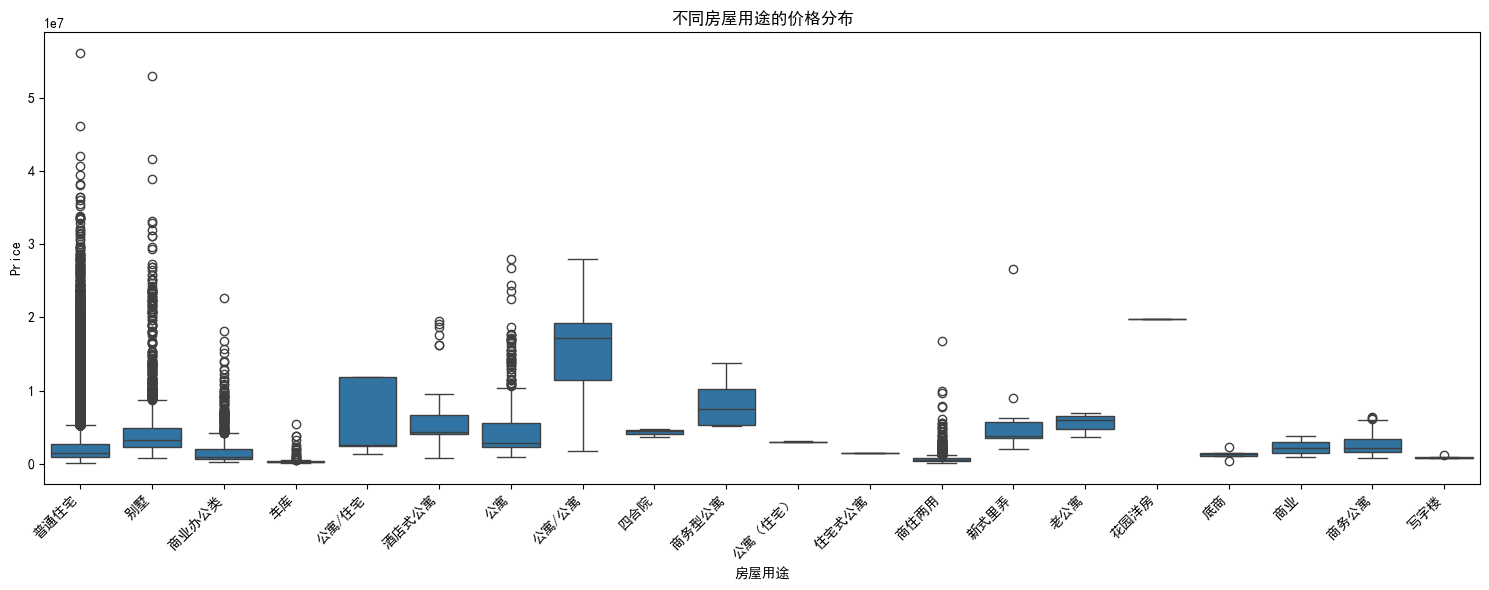

In [46]:
# 进行探索性分析
import matplotlib.pyplot as plt
import seaborn as sns
# 设置显示中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 1. 基本统计信息
# print("各房屋用途的价格分布统计：")
# price_stats = train.groupby('房屋用途')['Price'].describe()
# print(price_stats)

# 2. 箱线图可视化
plt.figure(figsize=(15, 6))
sns.boxplot(x='房屋用途', y='Price', data=train)
plt.xticks(rotation=45, ha='right')
plt.title('不同房屋用途的价格分布')
# 调整布局，确保x轴标签完全显示
plt.tight_layout()
plt.show()

In [47]:
# 创建进一步合并的映射字典
usage_mapping_further = {
    '普通住宅': '住宅',
    '商住两用': '住宅',
    '别墅': '住宅',
    '花园洋房': '住宅',
    '商业办公类': '商业',
    '车库': '车库',
    '公寓': '公寓',
    '商务公寓': '公寓',
    '酒店式公寓': '公寓',
    '公寓/公寓': '公寓',
    '商务型公寓': '公寓',
    '公寓/住宅': '公寓',
    '底商': '商业',
    '写字楼': '商业',
    '四合院': '住宅',  # 将四合院合并为住宅
    '老公寓': '公寓',
    '商业': '商业',
    '公寓（住宅）': '公寓',
    '住宅式公寓': '公寓',
    '新式里弄': '住宅'  # 将新式里弄合并为住宅
}

# 应用进一步合并的映射，创建新的标准化列
train['房屋用途_进一步标准'] = train['房屋用途'].map(usage_mapping_further)


In [48]:
# 显示整合后的分类
print("\n整合后的房屋用途分类：")
print(train['房屋用途_进一步标准'].value_counts())


整合后的房屋用途分类：
房屋用途_进一步标准
住宅    101211
商业      1539
车库       580
公寓       540
Name: count, dtype: int64


In [49]:
# 对“房屋用途_进一步标准”进行 One-Hot 编码
usage_dummies_further = pd.get_dummies(train['房屋用途_进一步标准'], prefix='房屋用途')

# 拼接回原数据集
train = pd.concat([train, usage_dummies_further], axis=1)

# 查看结果
train[['房屋用途', '房屋用途_进一步标准'] + list(usage_dummies_further.columns)].sample(10, random_state=111)

,房屋用途,房屋用途_进一步标准,房屋用途_住宅,房屋用途_公寓,房屋用途_商业,房屋用途_车库
92052,普通住宅,住宅,True,False,False,False
22088,普通住宅,住宅,True,False,False,False
91045,普通住宅,住宅,True,False,False,False
23282,普通住宅,住宅,True,False,False,False
34552,普通住宅,住宅,True,False,False,False
43726,普通住宅,住宅,True,False,False,False
82232,普通住宅,住宅,True,False,False,False
54452,普通住宅,住宅,True,False,False,False
78277,普通住宅,住宅,True,False,False,False
47404,普通住宅,住宅,True,False,False,False


In [50]:
# (10)房屋年限
train['房屋年限'].value_counts() # 3类

房屋年限
满五年     34896
满两年     15361
未满两年     9104
Name: count, dtype: int64

In [51]:
# (10)房屋年限
# 生成哑变量，保持缺失值
train['年限_满五'] = train['房屋年限'].apply(lambda x: 1 if x=='满五年' else (None if pd.isna(x) else 0))
train['年限_满二'] = train['房屋年限'].apply(lambda x: 1 if x=='满两年' else (None if pd.isna(x) else 0))
train['年限_未满二'] = train['房屋年限'].apply(lambda x: 1 if x=='未满两年' else (None if pd.isna(x) else 0))

In [52]:
# 显示结果
print("房屋年限及其哑变量（随机10行）：")
print(train[['房屋年限', '年限_满五', '年限_满二', '年限_未满二']].sample(10))

房屋年限及其哑变量（随机10行）：
       房屋年限  年限_满五  年限_满二  年限_未满二
12275   满五年    1.0    0.0     0.0
27707   满五年    1.0    0.0     0.0
68485  未满两年    0.0    0.0     1.0
72326   满五年    1.0    0.0     0.0
70978   满五年    1.0    0.0     0.0
47689   NaN    NaN    NaN     NaN
47178   NaN    NaN    NaN     NaN
96396   满五年    1.0    0.0     0.0
52503   NaN    NaN    NaN     NaN
11478   满五年    1.0    0.0     0.0


In [53]:
# (12)产权所属
train['产权所属'].value_counts() # 2类，共有/非共有

产权所属
非共有    73724
共有     30147
Name: count, dtype: int64

In [54]:
train['共有产权'] = train['产权所属'].apply(lambda x: 1 if x=='共有' else (None if pd.isna(x) else 0))

In [55]:
print(train[['产权所属']+['共有产权']].sample(10))

      产权所属  共有产权
16980  非共有     0
80496  非共有     0
5697   非共有     0
45788  非共有     0
67607   共有     1
33204   共有     1
81016   共有     1
44455  非共有     0
50555   共有     1
2869   非共有     0


In [56]:
# (13)房屋优势（这个只是做补充，可能只需要单独生成一个地铁列）我觉得可以drop了，有效信息很少
print(train['房屋优势'].value_counts())
 # 27类

房屋优势
装修              9429
地铁、房本满五年        6745
装修、房本满五年        6128
装修、             5542
地铁、装修、房本满五年     5065
地铁、             4818
、房本满五年          4492
、               3857
房本满五年           3782
地铁、装修           3171
地铁              3117
装修、房本满五年、       2873
装修、房本满两年        2462
地铁、房本满两年        2278
装修、房本满两年、       2163
地铁、装修、房本满五年、    2158
房本满两年           1984
地铁、装修、          1879
、房本满五年、         1751
、房本满两年          1716
地铁、房本满五年、       1640
地铁、装修、房本满两年     1479
、房本满两年、         1302
地铁、装修、房本满两年、     972
地铁、房本满两年、        755
房本满五年、           588
房本满两年、           489
Name: count, dtype: int64


In [57]:
# (13)房屋优势 - 提取有用信息
# 1. 地铁
train['优势_地铁'] = train['房屋优势'].str.contains('地铁').astype(float)  # 用float以保持与其他特征一致

# 2. 从房屋优势补充房本年限信息
mask_五年 = train['房屋优势'].str.contains('满五年', na=False)
mask_两年 = train['房屋优势'].str.contains('满两年', na=False)

# 用房屋优势的信息补充年限信息
train.loc[mask_五年 & train['年限_满五'].isna(), '年限_满五'] = 1.0
train.loc[mask_两年 & train['年限_满二'].isna(), '年限_满二'] = 1.0

# 3. 从房屋优势补充装修信息
# 先创建装修标志列
train['装修_有无'] = None  # 初始化为空

# 从装修情况列补充信息
train.loc[train['装修情况'].isin(['精装', '简装']), '装修_有无'] = 1.0
train.loc[train['装修情况'].isin(['毛坯','其他']), '装修_有无'] = 0.0

# 从房屋优势补充装修信息（只补充缺失的部分）
mask_装修 = train['房屋优势'].str.contains('装修', na=False)
train.loc[mask_装修 & train['装修_有无'].isna(), '装修_有无'] = 1.0


In [58]:
# 显示原始特征和新生成特征的对比
print("原始数据和提取的特征对比（随机10行）：")
print("\n1. 房屋优势与地铁特征的对比：")
print(train[['房屋优势', '优势_地铁', '年限_满五', '年限_满二', '装修情况', '装修_有无']].sample(10))

原始数据和提取的特征对比（随机10行）：

1. 房屋优势与地铁特征的对比：
             房屋优势  优势_地铁  年限_满五  年限_满二 装修情况 装修_有无
15762    地铁、房本满五年    1.0    1.0    0.0   精装   1.0
103858        NaN    NaN    NaN    NaN   简装   1.0
58843          地铁    1.0    NaN    NaN   简装   1.0
96650    装修、房本满五年    0.0    1.0    0.0   精装   1.0
23845    装修、房本满两年    0.0    0.0    1.0   毛坯   0.0
27019   装修、房本满两年、    0.0    0.0    1.0   毛坯   0.0
20918    装修、房本满五年    0.0    1.0    0.0   精装   1.0
64860         NaN    NaN    NaN    NaN   精装   1.0
831      地铁、房本满两年    1.0    0.0    1.0   简装   1.0
5683     地铁、房本满五年    1.0    1.0    0.0  NaN  None


In [59]:
# (14)物业类别
print(train['物业类别'].value_counts()) # 230类

物业类别
普通住宅                              25558
普通住宅/底商                            5466
普通住宅/商业/底商                         4752
车库/普通住宅                            4586
车库/普通住宅/商业/底商                      4242
                                  ...  
普通住宅/花园洋房/新式里弄/旧式里弄/老公寓               1
普通住宅/写字楼/商业/工业厂房/商业办公类/公寓/商务公寓        1
写字楼/商业办公类/公寓                          1
普通住宅/写字楼/商业/工业厂房/底商/公寓                1
车库/写字楼/商业/商住两用                        1
Name: count, Length: 230, dtype: int64


In [60]:
# 1. 获取所有物业类别组合
all_combinations = train['物业类别'].dropna().unique()
print("所有不同的物业类别组合数量：", len(all_combinations))

# 2. 提取所有独立的物业类别
unique_categories = set()
for combo in all_combinations:
    categories = combo.split('/')
    unique_categories.update(categories)

# 3. 按字母顺序排序并展示所有独立的物业类别
sorted_categories = sorted(unique_categories)
print("\n所有独立的物业类别（按字母排序）：")
for i, category in enumerate(sorted_categories, 1):
    print(f"{i}. {category}")

print(f"\n总共有 {len(sorted_categories)} 种独立的物业类别")

所有不同的物业类别组合数量： 230

所有独立的物业类别（按字母排序）：
1. 人防车位
2. 住宅
3. 住宅式公寓
4. 公寓
5. 公寓（住宅）
6. 写字楼
7. 别墅
8. 单身公寓（住宅）
9. 商业
10. 商业办公类
11. 商住两用
12. 商务公寓
13. 商务型公寓
14. 四合院
15. 地下仓储
16. 工业厂房
17. 平房
18. 库房
19. 底商
20. 新式里弄
21. 旧式里弄
22. 普通住宅
23. 老公寓
24. 花园洋房
25. 车库
26. 酒店式公寓

总共有 26 种独立的物业类别


In [61]:
# 创建进一步合并的映射字典
usage_mapping_further = {
    '普通住宅': '住宅',
    '商住两用': '住宅',
    '别墅': '住宅',
    '花园洋房': '住宅',
    '四合院': '住宅',  # 将四合院合并为住宅
    '新式里弄': '住宅',  # 将新式里弄合并为住宅
    '商业办公类': '商业',
    '车库': '车库',
    '公寓': '公寓',
    '商务公寓': '公寓',
    '酒店式公寓': '公寓',
    '商务型公寓': '公寓',
    '公寓（住宅）': '公寓',
    '住宅式公寓': '公寓',
    '老公寓': '公寓',
    '公寓/公寓': '公寓',
    '公寓/住宅': '公寓',
    '底商': '商业',
    '写字楼': '商业',
    '商业': '商业',
    '单身公寓（住宅）': '其他',
    '人防车位': '其他',
    '地下仓储': '其他',
    '工业厂房': '其他',
    '平房': '其他',
    '库房': '其他',
    '旧式里弄': '其他'
}

# 应用映射，创建新的标准化列
train['物业类别_进一步标准'] = train['物业类别'].map(usage_mapping_further)

# 查看合并后各类别的计数
train['物业类别_进一步标准'].value_counts()

物业类别_进一步标准
住宅    25843
商业      144
Name: count, dtype: int64

In [62]:
# (15)建筑年代
print(train['建筑年代'].value_counts()) # 736类，年份和时间段都有

建筑年代
2000-2012年    989
2015-2018年    951
2008-2014年    940
2008年         801
2013-2016年    779
             ... 
1983-1999年      1
1930-1996年      1
1989-2004年      1
1989-1991年      1
1988-1995年      1
Name: count, Length: 736, dtype: int64


In [63]:
# 处理建筑年代
def process_building_year(year_str):
    """处理建筑年代，返回中点年份和年代分类"""
    if pd.isna(year_str) or year_str == '未知':
        return pd.Series([None, None], 
                        index=['建筑年份', '建筑年代分类'])
    
    # 清理数据
    year_str = str(year_str).strip().replace('年', '')
    
    try:
        if '-' in year_str:
            # 处理年份范围，直接取中点
            start_year, end_year = map(int, year_str.split('-'))
            year = (start_year + end_year) // 2
        else:
            # 单一年份
            year = int(year_str)
        
        # 确定年代分类
        if year < 1970:
            decade = '1970年以前'
        elif year >= 2020:
            decade = '2020年及以后'
        else:
            # 1970-2019年按照每十年分类
            decade_start = (year // 10) * 10
            decade = f'{decade_start}年代'
            
        return pd.Series([year, decade],
                        index=['建筑年份', '建筑年代分类'])
    except:
        # 处理异常情况
        return pd.Series([None, None],
                        index=['建筑年份', '建筑年代分类'])

# 应用处理函数
year_data = train['建筑年代'].apply(process_building_year)
train[['建筑年份', '建筑年代分类']] = year_data

# 计算建筑物龄期（到交易时的年龄）
train['建筑物龄期'] = train.apply(
    lambda x: x['交易_年'] - x['建筑年份'] if pd.notna(x['交易_年']) and pd.notna(x['建筑年份']) else None,
    axis=1
)

In [64]:

# 展示处理结果
print("\n建筑年代分类分布：")
print(train['建筑年代分类'].value_counts())

print("\n建筑物龄期统计：")
print(train['建筑物龄期'].describe())

# 随机展示10个样本
print("\n随机10个样本的处理结果：")
sample_cols = ['建筑年代', '建筑年份', '建筑年代分类', '建筑物龄期']
print(train[sample_cols].sample(10))


建筑年代分类分布：
建筑年代分类
2010年代      29867
2000年代      25144
1990年代       9182
1980年代       3515
1970年代        679
2020年及以后      337
1970年以前        46
Name: count, dtype: int64

建筑物龄期统计：
count    68770.000000
mean        17.304130
std          8.936432
min          2.000000
25%         11.000000
50%         15.000000
75%         22.000000
max         90.000000
Name: 建筑物龄期, dtype: float64

随机10个样本的处理结果：
             建筑年代    建筑年份  建筑年代分类  建筑物龄期
16848  2010-2014年  2012.0  2010年代   10.0
51154         NaN     NaN    None    NaN
21915  2008-2014年  2011.0  2010年代   13.0
48965         NaN     NaN    None    NaN
67992         NaN     NaN    None    NaN
78849         NaN     NaN    None    NaN
81303  2012-2020年  2016.0  2010年代    6.0
19731  2014-2017年  2015.0  2010年代    9.0
36766  2010-2012年  2011.0  2010年代   13.0
91930       1999年  1999.0  1990年代   24.0


In [65]:
# (16)开发商——有鸡毛用

In [66]:
# (17)房屋总数 / 楼栋总数 = 栋均户数
# 改进1：添加微小常数避免除零错误
train['栋均户数'] = train['房屋总数'] / (train['楼栋总数'] + 1e-6)

# 改进2：对数变换缓解长尾分布
train['栋均户数_log'] = np.log1p(train['栋均户数'])

# 改进3：分箱离散化处理
bins = [0, 30, 60, 90, np.inf]
labels = ['低密度', '中密度', '高密度', '超高密度']
train['户数密度等级'] = pd.cut(train['栋均户数'], bins=bins, labels=labels)

In [67]:
# 对 '户数密度等级' 进行 One-Hot 编码
density_dummies = pd.get_dummies(train['户数密度等级'], prefix='户数密度')

# 拼接 One-Hot 编码后的列回原数据集
train = pd.concat([train, density_dummies], axis=1)

# 查看结果
train[['栋均户数', '户数密度等级'] + list(density_dummies.columns)].sample(10, random_state=111)

,栋均户数,户数密度等级,户数密度_低密度,户数密度_中密度,户数密度_高密度,户数密度_超高密度
92052,239.999880,超高密度,False,False,False,True
22088,91.666656,超高密度,False,False,False,True
91045,382.799923,超高密度,False,False,False,True
23282,265.666578,超高密度,False,False,False,True
34552,NaN,NaN,False,False,False,False
43726,NaN,NaN,False,False,False,False
82232,40.549998,中密度,False,True,False,False
54452,122.461529,超高密度,False,False,False,True
78277,105.666655,超高密度,False,False,False,True
47404,NaN,NaN,False,False,False,False


In [68]:
# 展示原始列和新列（不设置随机种子）
print("\n随机抽样特征对比：")
sample_cols = ['房屋总数', '楼栋总数',
               '栋均户数', '栋均户数_log']
print(train[sample_cols].sample(5))  # 每次运行结果不同



随机抽样特征对比：
         房屋总数  楼栋总数        栋均户数  栋均户数_log
80965  1456.0  10.0  145.599985  4.987708
30872   550.0  12.0   45.833330  3.846595
38397  4388.0  75.0   58.506666  4.086088
94719     NaN   NaN         NaN       NaN
64984  9342.0  68.0  137.382351  4.930021


In [69]:
# (18)物业公司——有鸡毛用

In [70]:
# (19)物业费
print(train['物业费'].value_counts()) # 736类，年份和时间段都有

物业费
2.8         2740
1.2         2293
1           2128
1.8         1906
1.5         1458
            ... 
3.9-5.95       1
6.9            1
6.78           1
3.1-5          1
2.9-3          1
Name: count, Length: 1021, dtype: int64


In [71]:
# 处理函数
def process_property_fee(fee_str):
    # 如果 fee_str 是 float 类型或 None，转换为字符串并进行处理
    fee_str = str(fee_str).strip()  # 转换为字符串并去除两边空格
    
    # 如果是空字符串或无效值，返回默认值
    if not fee_str or '未知' in fee_str:
        return None, None, None  # 不需要跨度，只有最小、最大和中间值
    
    # 处理单一值
    if '-' not in fee_str:
        fee = float(fee_str)
        return fee, fee, fee  # 单一值的最小、最大值相等，中间值也相等

    # 处理范围值
    min_fee, max_fee = fee_str.split('-')
    min_fee = float(min_fee)
    max_fee = float(max_fee)
    mid_fee = (min_fee + max_fee) / 2  # 计算均值
    return min_fee, max_fee, mid_fee  # 返回最小值、最大值、中间值

# 处理物业费
train[['物业费_最小', '物业费_最大', '物业费_均值']] = train['物业费'].apply(lambda x: pd.Series(process_property_fee(x) if x else (None, None, None)))

In [72]:
# train = train.loc[:, ~train.T.duplicated()]
train[['物业费'] + ['物业费_最小'] + ['物业费_最大'] + ['物业费_均值']].sample(100)

,物业费,物业费_最小,物业费_最大,物业费_均值
4476,0.6,0.60,0.60,0.600
94191,2.8-2.98,2.80,2.98,2.890
41675,2.6,2.60,2.60,2.600
8604,0.5-0.8,0.50,0.80,0.650
59199,NaN,NaN,NaN,NaN
...,...,...,...,...
96197,3.29-3.5,3.29,3.50,3.395
23650,NaN,NaN,NaN,NaN
84210,2.8,2.80,2.80,2.800
23282,1.2-2,1.20,2.00,1.600


In [73]:
# (20)建筑结构_comm
print(train['建筑结构_comm'].value_counts()) # 15类

建筑结构_comm
塔楼               18170
板楼               15698
塔楼/板楼/塔板结合       10484
塔楼/板楼            10139
板楼/塔板结合           6270
塔板结合              5255
塔楼/塔板结合           4712
塔楼/板楼/塔板结合/平房     1277
塔楼/板楼/平房           825
板楼/平房              612
塔楼/平房              551
板楼/塔板结合/平房         441
塔板结合/平房            172
平房                 135
塔楼/塔板结合/平房          11
Name: count, dtype: int64


In [74]:
# 步骤 1: 将 NaN 或其他非字符串值替换为空字符串
train.loc[:, '建筑结构_comm'] = train['建筑结构_comm'].fillna('')

# 步骤 2: 获取所有唯一的取值组合，并将它们用"/"连接
all_combinations = train['建筑结构_comm'].unique()

# 步骤 3: 对每个组合，拆分为单个特征并生成虚拟变量
features_set = set()
for combination in all_combinations:
    if combination:  # 确保不为空
        features_set.update(combination.split('/'))

# 步骤 4: 为每个特征生成虚拟变量，虚拟变量名以'楼型_'开头
for feature in features_set:
    # 用apply处理，每个特征如果在建筑结构_comm中存在，则置为1，否则为0；如果原始值为空则为NaN
    train.loc[:, f'楼型_{feature}'] = train['建筑结构_comm'].apply(
        lambda x: 1 if feature in x else (None if x == '' else 0)
    )

In [75]:
# 展示所有楼型开头的变量
print("\n生成的楼型特征列表：")
building_features = [col for col in train.columns if col.startswith('楼型_')]
print(building_features)
# 展示包含原始字段和新建特征的样本
print("\n特征数据样本：")
sample_cols = ['建筑结构_comm', *building_features]
print(train[sample_cols].sample(10))  # 完全随机抽样


生成的楼型特征列表：
['楼型_平房', '楼型_塔楼', '楼型_板楼', '楼型_塔板结合']

特征数据样本：
        建筑结构_comm  楼型_平房  楼型_塔楼  楼型_板楼  楼型_塔板结合
12063          板楼    0.0    0.0    1.0      0.0
49620                NaN    NaN    NaN      NaN
89271          板楼    0.0    0.0    1.0      0.0
9055         塔板结合    0.0    0.0    0.0      1.0
17399  塔楼/板楼/塔板结合    0.0    1.0    1.0      1.0
16427          板楼    0.0    0.0    1.0      0.0
8137   塔楼/板楼/塔板结合    0.0    1.0    1.0      1.0
16682  塔楼/板楼/塔板结合    0.0    1.0    1.0      1.0
65227                NaN    NaN    NaN      NaN
70797       塔楼/板楼    0.0    1.0    1.0      0.0


In [76]:
# (21)产权描述
print(train['产权描述'].value_counts()) # 15类

产权描述
商品房                    42889
商品房/使用权                 5586
商品房/私产                  4941
商品房/使用权/私产              2118
商品房/房改房                 1841
                       ...  
集资房                        1
商品房/使用权/乡产                 1
商品房/使用权/乡产/私产              1
商品房/安居型商品房                 1
商品房/经济适用房/动迁安置房/使用权        1
Name: count, Length: 168, dtype: int64


In [77]:
# # # # # 删除所有以 '产权_' 开头的特征列
# train.drop(columns=[col for col in train.columns if col.startswith('产权_')], inplace=True)
# # # train.sample(10, random_state=111)[['产权描述'] + [col for col in train.columns if col.startswith('产权_')]]
# # # # 将空字符串替换为缺失值 (NaN)
# # # # train['产权描述'] = train['产权描述'].replace('', np.nan)

In [78]:
# 步骤 1: 获取所有唯一的产权描述组合
all_combinations = train['产权描述'].dropna().unique()  # 去掉 NaN

# 步骤 2: 获取所有特征并拆分
features_set = set()
for combination in all_combinations:
    if isinstance(combination, str):  # 只处理字符串类型
        # 拆分描述组合并更新特征集
        features_set.update(combination.split('/'))

# 打印所有拆分出的特征（供检查）
print("所有唯一特征：", features_set)


所有唯一特征： {'定向安置房', '央产房', '集资房', '安居型商品房', '私产', '校产', '房改房', '动迁安置房', '售后公房', '拆迁还建房', '廉租房', '自住型商品房', '经济适用房', '公租房', '商品房', '军产', '共有产权房', '一类经济适用房', '宅基房', '限价商品房', '回迁房', '已购公房', '使用权', '乡产', '二类经济适用房'}


In [79]:
# 定义映射规则
merge_rules = {
    '商品房类': ['商品房', '自住型商品房', '限价商品房'],
    '经济适用房类': ['经济适用房', '一类经济适用房', '二类经济适用房'],
    '安置房类': ['拆迁还建房', '动迁安置房', '回迁房', '定向安置房'],
    '公房类': ['公租房', '廉租房', '售后公房', '集资房', '已购公房'],
    '私产类': ['私产', '军产', '央产房', '乡产', '校产'],
    '其他类': ['安居型商品房', '共有产权房', '使用权', '宅基房']
}

# 步骤 1: 根据合并规则创建新列
def apply_merge_rules(df, merge_rules):
    # 为每个大类创建新列
    for category, keywords in merge_rules.items():
        # 初始化该分类列，所有行默认为 0
        df[f'产权_{category}'] = 0

        # 遍历每行产权描述
        for idx, row in df.iterrows():
            # 如果产权描述不是空值
            if isinstance(row['产权描述'], str):
                # 拆分产权描述（按 / 拆分）
                features = set(row['产权描述'].split('/'))

                # 检查是否有关键词出现在拆分后的特征中
                if any(keyword in features for keyword in keywords):
                    df.at[idx, f'产权_{category}'] = 1  # 如果匹配，标记为 1

    return df

# 执行操作
train = apply_merge_rules(train, merge_rules)

In [80]:
# 输出查看结果，确保只有6列
train.sample(10)[['产权描述'] + [col for col in train.columns if col.startswith('产权_')]]

,产权描述,产权_商品房类,产权_经济适用房类,产权_安置房类,产权_公房类,产权_私产类,产权_其他类
66148,NaN,0,0,0,0,0,0
21029,商品房,1,0,0,0,0,0
87501,NaN,0,0,0,0,0,0
79136,商品房/经济适用房,1,1,0,0,0,0
26793,商品房/限价商品房/使用权,1,0,0,0,0,1
2074,商品房/一类经济适用房,1,1,0,0,0,0
81877,商品房/使用权/私产,1,0,0,0,1,1
2342,商品房/私产,1,0,0,0,1,0
60565,NaN,0,0,0,0,0,0
87225,NaN,0,0,0,0,0,0


In [81]:
# (22) 供水
print(train['供水'].value_counts()) # 3类，民商

供水
民水       47635
商水/民水    25181
商水         757
Name: count, dtype: int64


In [82]:
# 先生成哑变量
dummies = pd.get_dummies(train['供水'], prefix='供水')

# 再用 where() 保留缺失：如果原列是 NaN，对应新列也变 NaN
dummies = dummies.where(train['供水'].notna(), np.nan)

# 合并回原数据
train = pd.concat([train, dummies], axis=1)

In [83]:
# 随机显示 10 行，只选出指定列
cols = [c for c in train.columns if c.startswith('供水')]
train.loc[:, cols].sample(10)

,供水,供水_商水,供水_商水/民水,供水_民水
66360,NaN,NaN,NaN,NaN
94882,民水,False,False,True
36019,商水/民水,False,True,False
23566,商水/民水,False,True,False
92603,民水,False,False,True
39639,民水,False,False,True
45295,民水,False,False,True
24499,民水,False,False,True
100947,民水,False,False,True
37906,商水/民水,False,True,False


In [84]:
# (23) 供暖
print(train['供暖'].value_counts()) # 总的来说，3类

供暖
集中供暖            18547
自采暖              8326
集中供暖/自采暖         3629
无供暖               274
自采暖/无供暖           103
集中供暖/自采暖/无供暖       66
Name: count, dtype: int64


In [85]:
# 基本类别（可以从数据中提取唯一值的拆分后集合）
base_types = ['集中供暖', '自采暖', '无供暖']

# 创建空列
for t in base_types:
    train[t] = np.nan  # 先设为空，便于保留缺失

# 遍历每一行
for i, val in train['供暖'].items():
    if pd.isna(val):
        continue  # 缺失保留为 NaN
    types = val.split('/')  # 按 "/" 拆分
    weight = 1 / len(types)  # 平均分配权重
    for t in types:
        train.loc[i, t] = weight  # 填充权重

train = train.rename(columns={t: f'供暖_{t}' for t in base_types})

In [86]:
# 随机显示 10 行，只选出指定列
cols = [c for c in train.columns if c.startswith('供暖')]
train.loc[:, cols].sample(10)

,供暖,供暖_集中供暖,供暖_自采暖,供暖_无供暖
95490,NaN,NaN,NaN,NaN
80024,无供暖,NaN,NaN,1.0
94705,NaN,NaN,NaN,NaN
67583,NaN,NaN,NaN,NaN
65456,NaN,NaN,NaN,NaN
92751,NaN,NaN,NaN,NaN
40020,NaN,NaN,NaN,NaN
61379,NaN,NaN,NaN,NaN
95157,NaN,NaN,NaN,NaN
17725,集中供暖,1.0,NaN,NaN


In [87]:
# (24) 供电
print(train['供电'].value_counts()) # 

供电
民电       47086
商电/民电    25674
商电         819
Name: count, dtype: int64


In [88]:
# 先生成哑变量
dummies = pd.get_dummies(train['供电'], prefix='供电')

# 再用 where() 保留缺失：如果原列是 NaN，对应新列也变 NaN
dummies = dummies.where(train['供电'].notna(), np.nan)

# 合并回原数据
train = pd.concat([train, dummies], axis=1)

In [89]:
# 随机显示 10 行，只选出指定列
cols = [c for c in train.columns if c.startswith('供电')]
train.loc[:, cols].sample(10)

,供电,供电_商电,供电_商电/民电,供电_民电
41791,民电,False,False,True
100594,民电,False,False,True
72086,民电,False,False,True
15912,民电,False,False,True
99384,民电,False,False,True
102610,民电,False,False,True
39033,民电,False,False,True
36609,民电,False,False,True
68950,NaN,NaN,NaN,NaN
93521,民电,False,False,True


In [90]:
# (25) 燃气费
train['燃气费'].value_counts() # 只有数字和范围，以及空值

燃气费
2.61         14390
3.45         12488
1.98          8093
1.96          3378
3             3285
             ...  
1.73-1.75        1
1.74             1
1.8-1.98         1
1.73-1.74        1
2.18-2.68        1
Name: count, Length: 262, dtype: int64

In [91]:
# 定义通用费用处理函数
def process_fee(fee_str):
    """
    输入：单个燃气费字符串（可能是'2.5'、'2.5-3.0'或空值）
    输出：最小值、最大值、均值
    """
    if pd.isna(fee_str):
        return None, None, None
    
    fee_str = str(fee_str).strip()
    
    try:
        # 单一数值
        if '-' not in fee_str:
            fee = float(fee_str)
            return fee, fee, fee
        
        # 区间值：如 '1.73-1.75'
        parts = fee_str.split('-')
        if len(parts) == 2:
            min_fee = float(parts[0])
            max_fee = float(parts[1])
        else:
            # 处理异常格式（例如 '1.8-1.98-2.1'）时，只取前两个
            min_fee, max_fee = float(parts[0]), float(parts[1])
        mid_fee = (min_fee + max_fee) / 2
        return min_fee, max_fee, mid_fee
    except Exception:
        return None, None, None

# 应用于燃气费字段
train[['燃气费_最小', '燃气费_最大', '燃气费_均值']] = (
    train['燃气费']
    .apply(lambda x: pd.Series(process_fee(x)))
)

In [92]:
# train = train.loc[:, ~train.T.duplicated()]
train[['燃气费'] + ['燃气费_最小'] + ['燃气费_最大'] + ['燃气费_均值']].sample(100)

,燃气费,燃气费_最小,燃气费_最大,燃气费_均值
82719,3.45,3.45,3.45,3.45
96170,NaN,NaN,NaN,NaN
22051,2.46,2.46,2.46,2.46
98332,NaN,NaN,NaN,NaN
83521,2.95,2.95,2.95,2.95
...,...,...,...,...
45315,1.98,1.98,1.98,1.98
88122,3.45,3.45,3.45,3.45
102775,3.45,3.45,3.45,3.45
18309,2.46,2.46,2.46,2.46


In [93]:
# (26) 供热费
train['供热费'].value_counts() # 数字、范围

供热费
30        9688
1         4734
25        1915
24-30     1600
24        1522
          ... 
0.5-4        1
50           1
4            1
2.29         1
2.4-20       1
Name: count, Length: 129, dtype: int64

In [94]:
# 通用费用处理函数
def process_fee(fee_str):
    """
    输入：单个费用字符串（可能是 '30'、'24-30'、'未知'、None 等）
    输出：最小值、最大值、均值
    """
    if pd.isna(fee_str):
        return None, None, None
    
    fee_str = str(fee_str).strip()
    
    if not fee_str or '未知' in fee_str:
        return None, None, None

    try:
        # 单值情况
        if '-' not in fee_str:
            fee = float(fee_str)
            return fee, fee, fee
        
        # 区间情况，如 '24-30'
        parts = fee_str.split('-')
        if len(parts) == 2:
            min_fee = float(parts[0])
            max_fee = float(parts[1])
        else:
            # 若区间异常（如 '2.4-20-30'），取前两个
            min_fee, max_fee = float(parts[0]), float(parts[1])
        mid_fee = (min_fee + max_fee) / 2
        return min_fee, max_fee, mid_fee
    except Exception:
        return None, None, None


# === 对 “供热费” 列进行处理 ===
train[['供热费_最小', '供热费_最大', '供热费_均值']] = (
    train['供热费']
    .apply(lambda x: pd.Series(process_fee(x)))
)

In [95]:
print(train[['供热费', '供热费_最小', '供热费_最大', '供热费_均值']].sample(10))

          供热费  供热费_最小  供热费_最大  供热费_均值
101474    NaN     NaN     NaN     NaN
2806    30-43   30.00   43.00   36.50
28016     NaN     NaN     NaN     NaN
55697     NaN     NaN     NaN     NaN
67328     NaN     NaN     NaN     NaN
89329     NaN     NaN     NaN     NaN
58244     NaN     NaN     NaN     NaN
73840     NaN     NaN     NaN     NaN
84876     NaN     NaN     NaN     NaN
78334    5.91    5.91    5.91    5.91


In [96]:
# (27) 停车位
print(train['停车位'].value_counts()) # 

停车位
500.0     3214
200.0     2125
300.0     2004
600.0     1617
1000.0    1568
          ... 
1680.0       1
2110.0       1
1062.0       1
268.0        1
3644.0       1
Name: count, Length: 803, dtype: int64


In [97]:
# (28) 停车费用
train['停车费用'].value_counts() # 复杂无比

停车费用
150           9432
300           8406
400           7625
350           4978
450           3683
              ... 
251              1
地上110地下200       1
临保免费月保免费         1
临保无车库月保无车库       1
地上免费停车           1
Name: count, Length: 251, dtype: int64

In [98]:
import re
import numpy as np
import pandas as pd

def process_parking_fee_v2(text):
    if pd.isna(text):
        return np.nan, np.nan, np.nan

    s = str(text).strip()
    if not s:
        return np.nan, np.nan, np.nan

    # 特殊情况
    if any(x in s for x in ['暂无', '未知', '无法核实', '无法获知']):
        return np.nan, np.nan, np.nan
    if any(x in s for x in ['免费', '不收费', '无停车费', '无固定车位不收费', '目前免费']):
        return 0.0, 0.0, 0.0

    # 提取所有数字（包括小数、区间）
    s = s.replace('～', '-').replace('~', '-')
    nums = re.findall(r'\d+(?:\.\d+)?', s)
    if not nums:
        return np.nan, np.nan, np.nan
    nums = [float(x) for x in nums]

    # 若有“年”且无“月” -> 年费转月费
    if ('年' in s) and ('月' not in s):
        nums = [n / 12 for n in nums]

    # 若有“小时”，但没有“月”或“年” → 不算月费
    if ('小时' in s or '/时' in s) and not ('月' in s or '年' in s):
        return np.nan, np.nan, np.nan

    # 若是区间，例如 “300-400”
    if re.search(r'\d+\s*-\s*\d+', s):
        min_fee, max_fee = min(nums), max(nums)
    else:
        min_fee = min(nums)
        max_fee = max(nums)

    mean_fee = (min_fee + max_fee) / 2
    return round(min_fee, 2), round(max_fee, 2), round(mean_fee, 2)


samples = [
 "免费",
 "地上150元/月，地下300元/月",
 "地下300-400元/月/位",
 "临保2元/小时月保400元/月",
 "固定车位1400元/年",
 "800~1000",
 "每小时2元/位",
 "暂无",
 "地上:70元/月/位",
 "地上4元/小时/位"
]

for s in samples:
    print(s, "->", process_parking_fee_v2(s))

# 应用处理
train[['停车费_最小', '停车费_最大', '停车费_均值']] = train['停车费用'].apply(
    lambda x: pd.Series(process_parking_fee_v2(x))
)

免费 -> (0.0, 0.0, 0.0)
地上150元/月，地下300元/月 -> (150.0, 300.0, 225.0)
地下300-400元/月/位 -> (300.0, 400.0, 350.0)
临保2元/小时月保400元/月 -> (2.0, 400.0, 201.0)
固定车位1400元/年 -> (116.67, 116.67, 116.67)
800~1000 -> (800.0, 1000.0, 900.0)
每小时2元/位 -> (nan, nan, nan)
暂无 -> (nan, nan, nan)
地上:70元/月/位 -> (70.0, 70.0, 70.0)
地上4元/小时/位 -> (nan, nan, nan)


In [99]:
train[['停车费用', '停车费_最小', '停车费_最大', '停车费_均值']].sample(10)
# train = train.drop(train.filter(regex='^停车费_').columns, axis=1)

,停车费用,停车费_最小,停车费_最大,停车费_均值
44021,300,300.0,300.0,300.0
47861,350,350.0,350.0,350.0
54798,NaN,NaN,NaN,NaN
31675,100,100.0,100.0,100.0
9848,160,160.0,160.0,160.0
27703,80,80.0,80.0,80.0
43497,400,400.0,400.0,400.0
31155,NaN,NaN,NaN,NaN
75153,地下均价350元/月/位,350.0,350.0,350.0
90398,380,380.0,380.0,380.0


In [100]:
# (29) 环线
print(train.value_counts('环线'))

环线
内环内      10890
内环至中环     5160
五至六环      5068
外环外       3303
内环至外环     3219
中环至外环     2746
三至四环      2681
二至三环      2480
四至五环      2432
六环外       1887
二环内        553
Name: count, dtype: int64


In [101]:
# 定义合并规则
merge_ring_rules = {
    '内环范围': ['内环内', '内环至中环','二环内'],
    '中环至外环范围': ['内环至外环', '中环至外环', '三至四环', '二至三环', '四至五环'],
    '外环范围': ['外环外', '五至六环', '六环外']
}

# 步骤 1: 根据合并规则创建新列
def apply_ring_merge_rules(df, merge_ring_rules):
    # 为每个大类创建新列
    for category, keywords in merge_ring_rules.items():
        # 初始化该分类列，所有行默认为 0
        df[f'环线_{category}'] = 0

        # 遍历每行环线描述
        for idx, row in df.iterrows():
            # 如果环线描述不是空值
            if isinstance(row['环线'], str):
                # 拆分环线描述（按 / 拆分）
                features = set(row['环线'].split('/'))

                # 检查是否有关键词出现在拆分后的特征中
                if any(keyword in features for keyword in keywords):
                    df.at[idx, f'环线_{category}'] = 1  # 如果匹配，标记为 1

    return df

# 执行操作
train = apply_ring_merge_rules(train, merge_ring_rules)

# 输出查看结果，确保只有新生成的环线列
train.sample(10, random_state=111)[['环线'] + [col for col in train.columns if col.startswith('环线_')]]


,环线,环线_内环范围,环线_中环至外环范围,环线_外环范围
92052,NaN,0,0,0
22088,NaN,0,0,0
91045,NaN,0,0,0
23282,NaN,0,0,0
34552,NaN,0,0,0
43726,NaN,0,0,0
82232,NaN,0,0,0
54452,NaN,0,0,0
78277,NaN,0,0,0
47404,内环内,1,0,0


In [102]:
# 输出查看结果，确保只有新生成的环线列
train.sample(10)[['环线'] + [col for col in train.columns if col.startswith('环线_')]]
# 删除所有以 '环线_' 开头的列
# train = train.drop(columns=[col for col in train.columns if col.startswith('环线_')])

,环线,环线_内环范围,环线_中环至外环范围,环线_外环范围
75571,NaN,0,0,0
31387,内环内,1,0,0
23931,NaN,0,0,0
35614,NaN,0,0,0
79107,NaN,0,0,0
96269,NaN,0,0,0
84729,NaN,0,0,0
40538,内环内,1,0,0
20641,NaN,0,0,0
44469,NaN,0,0,0


### 文本分析一下

1- 核心卖点、户型介绍、周边配套、交通出行、客户反馈

2- 思路是用前三个给房子打一个分，最后一个给房子打一个分，一个广告分，一个使用分，一个平均分

In [103]:
import re

# === 原有特征字典 ===
FEATURE_DICT = {
    "户型格局": ["户型", "方正", "格局", "布局", "通透", "南北通透", "方正户型", "中间楼层", "高楼层", "低楼层", "视野好", "无遮挡视野"], 
    "装修精良": ["装修", "精装", "拎包", "简约装修", "现代装修", "全新装修", "保养好", "精美装修"],
    "采光与绿化": ["采光", "阳光", "无遮挡", "明亮", "朝南", "采光充足", "日照", "绿化", "园林", "环境", "空气", "景观", "绿地", "小区环境好", "安静", "安全", "门禁", "封闭式", "人车分流"],
    "交通便利": ["交通", "公交", "地铁", "轻轨", "出行", "便利", "地段好", "通勤方便"],
    "生活配套": ["配套", "商圈", "生活", "超市", "医院", "银行", "便利设施", "购物方便"],
    "学区优势": ["学区", "学校", "教育", "重点学校", "学区优质", "名校"],
    "价格合理": ["价格", "性价比", "价格合理", "价位合适", "价格优惠"]
}

# 默认权重
FEATURE_WEIGHT = {k: 1 for k in FEATURE_DICT.keys()}

# === 客户反馈情感词典（可扩展） ===
FEEDBACK_WEIGHTS = {
    # 正面
    "宽敞": 2, "整洁": 2, "明亮": 2, "舒适": 2, "安全": 2, "安静": 2, "方便": 1,
    "干净": 2, "新": 1, "优美": 2, "绿化": 2, "设施完善": 2, "物业好": 2, "交通便利": 2,
    "户型方正": 2, "采光好": 2, "精装修": 2, "生活便利": 1, "面积适中": 1, "采暖好": 2,
    # 负面
    "老旧": -2, "噪音": -2, "差": -2, "潮湿": -2, "漏水": -3, "破": -2, "狭窄": -2,
    "污染": -2, "拥挤": -2, "不便": -1, "电梯慢": -2, "物业差": -2, "空调老旧": -2,
    "采光差": -2, "装修差": -2, "不安全": -2, "排水慢": -2, "气味刺鼻": -2,
    "违章改造": -3, "维修慢": -2, "水压低": -2, "楼道脏乱": -2, "阳台漏水": -2,
    "通风死角": -2, "设施损坏": -2, "道路不平": -2, "交通不便": -2, "噪声扰民": -2,
    "墙角发黑": -2, "地面不平": -2, "厕所返味": -2, "绿化荒废": -2
}

def score_features(text):
    text = text.lower()
    total_weight = sum(FEATURE_WEIGHT.values())
    weighted_sum = 0
    for feature, keywords in FEATURE_DICT.items():
        match = any(k.lower() in text for k in keywords)
        score = 1 if match else 0
        weighted_sum += score * FEATURE_WEIGHT[feature]
    total_score = weighted_sum / total_weight if total_weight > 0 else 0
    return total_score

def score_feedback(text):
    if not text or text.strip() == "":
        return 0.5
    sentences = re.split('[，。；、]', text)
    total_score = 0
    total_weight = 0
    for sentence in sentences:
        s_score = 0
        s_weight = 0
        for word, weight in FEEDBACK_WEIGHTS.items():
            if word in sentence:
                s_score += weight
                s_weight += abs(weight)
        if s_weight > 0:
            total_score += s_score / s_weight
            total_weight += 1
    if total_weight == 0:
        return 0.5
    avg_score = total_score / total_weight  # [-1,1]
    final_score = (avg_score + 1) / 2       # 归一到 [0,1]
    return final_score

def score_overall(row, feature_weight=1, feedback_weight=2):
    # 前四个文本列合并打分
    text_feature = ' '.join([str(row[col]) for col in ['核心卖点','户型介绍','周边配套','交通出行']])
    feat_score = score_features(text_feature)
    fb_score = score_feedback(str(row['客户反馈']))
    overall = (feat_score * feature_weight + fb_score * feedback_weight) / (feature_weight + feedback_weight)
    return overall

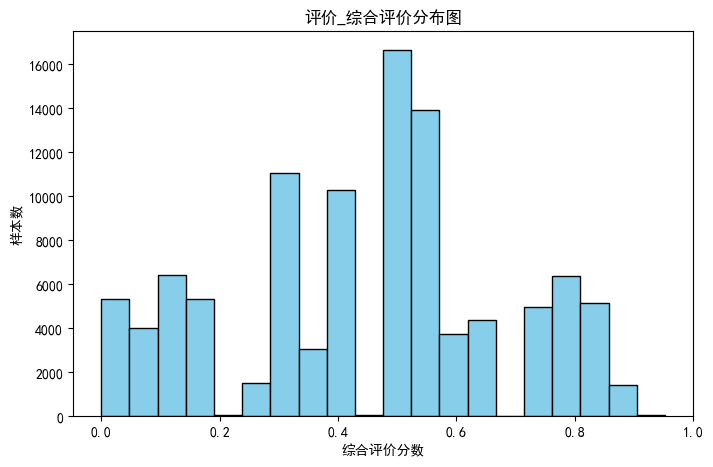

In [104]:
# === 应用到 train ===
train['评价_综合评价'] = train.apply(score_overall, axis=1)

# === 画分布图 ===
plt.figure(figsize=(8,5))
plt.hist(train['评价_综合评价'], bins=20, color='skyblue', edgecolor='black')
plt.title('评价_综合评价分布图')
plt.xlabel('综合评价分数')
plt.ylabel('样本数')
plt.show()

In [105]:
# 查看结果
train[['核心卖点', '户型介绍', '周边配套', '交通出行', '客户反馈', '评价_综合评价']].sample(10)

,核心卖点,户型介绍,周边配套,交通出行,客户反馈,评价_综合评价
57762,精装修三开间朝南少有的户型,此房位于小区中间位置，中间楼层，采光充沛，一梯两户，进门客厅通透户型，南北房，格局方正，全明户型,NaN,NaN,隔离噪声差，综合考虑下来，墙角渗水，严格来说，楼下餐饮油烟,0.142857
95224,此房房产证满两年，楼体新，楼层朝向好，户型结构好，通风采光好,NaN,花山两龙综合市场，阳光购物广场等，配套成熟穗广深城际花山站。,该小区属于机场板块，很多机场员工入住本小区，交通便利，太广高速花山出口1公里即到，门口有有1...,老实说，楼道照明正常，采暖系统老旧,0.190476
7055,满五唯一，户型方正，中间楼层，楼龄新，1997年，安静不临街,NaN,出小区门口右拐步行150米左右（百度地图）到菜市场，有京客隆、德隆、物美等。商场有新奥购物广...,沿八达岭辅路步行286米（百度地图）到达北沙滩地铁15号线北沙滩站，小区门口西侧是南沙滩公交...,采暖充足，客观上看，社区氛围好,0.523810
74011,交通便利，楼层适中，配套设施齐全，环境舒适，采光通透好,NaN,配套：富元广场、希尔顿酒店、艾美酒店、世荣风景广场、建粤商务、科创：地税局、公安局、检察院、...,NaN,老实说，路况良好，相比较之下，面积适中，坦白说，采光通透,0.857143
83339,此房满两年，价格实惠，三室一卫，采光采阳好,NaN,医院：明珠医院、延安医院、社区卫生服务站。生活便利店：沃尔玛、日新达。幼儿园：和润幼儿园、小...,东骧神骏位于：东风东路延长线金马立交桥前行800米金马路811号，公交路线:28路、111路...,总体印象中还行，光线均匀，相比较之下，温度适宜,0.523810
52252,小区中间位置纯毛坯满二年前排是洋房，采光好,NaN,小区东门就是邻里中心，一站式购物，方便快捷！小区南面有菜市场，甪直实验校园，镇上有甪直医院，...,交通较为方便，北依甪直大道，东靠绕城东线，开车到金鸡湖东CBD.独墅湖高教园区十分方便，还有...,靠近学校，从另一方面讲，通风一般,0.476190
87024,赵王建材城南，南北通透户型，有证可落户，采光好，新证。,赵王建材城南，南北通透户型，有证可落户，采光好，新证可贷款，精装修，，，,赵王建材城南，南北通透户型，有证可落户，采光好，新证可贷款，精装修，,NaN,安防系统运行中，室内采光均衡，仔细一看，电线杂乱,0.476190
548,房子是普通住宅，业主稳定出售户型方正,房源是西南朝向，公园六号经典三居两卫户型，通风好，采光*不错,小区*北侧400米左右永安公园，距离G6辅路300米左右，距离昌平地铁站1200米左右，距离...,小区西侧有水屯站多路公交车经过，北侧有花样年华车站都方便，自驾开车上下高速出口离小区也*,总体上看，水费正常收费，说真的，门窗松动,0.523810
17583,万科开发商，值得信赖，小区有休闲娱乐设施，适合老幼居住,此房为一层带小院，位置好，全天采光，户型方正，小院可根据自己喜好打理,NaN,NaN,标准水平，电梯慢，整体还可以，违章改造,0.095238
10865,NaN,NaN,NaN,NaN,说到底，采暖系统老旧，与其说，设计精致，签约手续正规,0.000000


In [106]:
# train = train.loc[:, ~train.T.duplicated()]
train.sample(100)
train.to_csv('train_preview.csv', index=False)  # 或者 train.to_excel('train_preview.xlsx', index=False)

### 离群值、插值

In [107]:
# 读取 CSV 文件
train_preview = pd.read_csv('train_preview.csv')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4064\3978823928.py:2: DtypeWarning: Columns (3,32,34,43,46,48,49,51,110,112) have mixed types. Specify dtype option on import or set low_memory=False.
  train_preview = pd.read_csv('train_preview.csv')


In [108]:
# 删除所有object类型列
train_preview = train_preview.drop(columns=train_preview.select_dtypes(include=['object']).columns)
# 将 train_preview 中所有非 object 类型的列转换为 float
train_preview = train_preview.astype({col: 'float' for col in train_preview.columns if train_preview[col].dtype != 'O'})
train_preview.sample(10)

,城市,区域,板块,Price,建筑面积,套内面积,抵押信息,lon,lat,年份,...,供热费_最小,供热费_最大,供热费_均值,停车费_最小,停车费_最大,停车费_均值,环线_内环范围,环线_中环至外环范围,环线_外环范围,评价_综合评价
47046,2.0,76.0,1176.0,1.045517e+06,84.00,NaN,NaN,107.600291,30.616042,2022.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.333333
82959,8.0,38.0,39.0,9.996486e+05,86.12,NaN,NaN,103.783267,25.970498,2021.0,...,1.0,6.0,3.5,300.0,300.0,300.0,0.0,0.0,0.0,0.476190
71097,4.0,117.0,522.0,3.536142e+06,47.69,NaN,NaN,122.463239,32.220628,2021.0,...,NaN,NaN,NaN,300.0,300.0,300.0,1.0,0.0,0.0,0.571429
64091,3.0,107.0,607.0,1.126826e+06,68.92,NaN,NaN,121.579060,32.325420,2021.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.809524
23271,2.0,76.0,1159.0,8.757459e+05,85.00,NaN,NaN,107.574994,30.602259,2019.0,...,1.0,1.0,1.0,480.0,480.0,480.0,0.0,0.0,0.0,0.761905
83225,8.0,93.0,191.0,8.021096e+05,81.13,65.04,NaN,103.780698,26.100097,2021.0,...,NaN,NaN,NaN,400.0,400.0,400.0,0.0,0.0,0.0,0.428571
60297,3.0,49.0,765.0,3.978791e+06,95.32,NaN,NaN,121.768686,32.270273,2021.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.666667
54568,3.0,20.0,793.0,2.152656e+06,109.58,NaN,NaN,121.881261,32.293381,2021.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.523810
63881,3.0,49.0,765.0,1.413210e+07,179.27,NaN,NaN,121.762981,32.267298,2021.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.333333
89221,10.0,26.0,936.0,1.580576e+06,94.01,75.15,NaN,114.807956,24.301504,2020.0,...,NaN,NaN,NaN,300.0,300.0,300.0,0.0,0.0,0.0,0.476190


In [109]:
for col, dtype in zip(train_preview.columns, train_preview.dtypes):
    print(col, dtype)

城市 float64
区域 float64
板块 float64
Price float64
建筑面积 float64
套内面积 float64
抵押信息 float64
lon float64
lat float64
年份 float64
区县 float64
板块_comm float64
房屋总数 float64
楼栋总数 float64
绿化率 float64
容积率 float64
停车位 float64
coord_x float64
coord_y float64
房型_室 float64
房型_厅 float64
房型_厨 float64
房型_卫 float64
房型_房间 float64
相对楼层_中楼层 float64
相对楼层_低楼层 float64
相对楼层_地下室 float64
相对楼层_底层 float64
相对楼层_顶层 float64
相对楼层_高楼层 float64
总共楼层 float64
朝向_东 float64
朝向_南 float64
朝向_西 float64
朝向_北 float64
结构_未知结构 float64
结构_框架结构 float64
结构_混合结构 float64
结构_砖木结构 float64
结构_砖混结构 float64
结构_钢混结构 float64
结构_钢结构 float64
装修_其他 float64
装修_毛坯 float64
装修_简装 float64
装修_精装 float64
梯户_电梯 float64
梯户_每层户数 float64
有电梯 float64
是否别墅 float64
交易_年 float64
交易_月 float64
交易_日 float64
交易权属_商品房 float64
交易权属_安置房 float64
交易权属_已购公房 float64
交易权属_私产或央产房 float64
交易权属_经济适用房 float64
上次交易_年 float64
上次交易_月 float64
上次交易_日 float64
房屋用途_住宅 float64
房屋用途_公寓 float64
房屋用途_商业 float64
房屋用途_车库 float64
年限_满五 float64
年限_满二 float64
年限_未满二 float64
共有产权 float64
优势_地铁 floa

In [110]:
# 计算每一列缺失值的比例
missing_percentage = train_preview.isnull().mean() * 100

# 输出缺失值比例大于 35% 的列
high_missing_columns = missing_percentage[missing_percentage > 35]
print(f"缺失值超过35%的列:\n{high_missing_columns}")

# 删除这些列
# train_preview = train_preview.drop(columns=high_missing_columns.index)  # 确保删除的是正确的列

# 输出处理后的数据集
print(train_preview.sample(10))

缺失值超过35%的列:
套内面积        65.357029
抵押信息       100.000000
年限_满五       42.424738
年限_满二       42.467099
年限_未满二      42.851229
供暖_集中供暖     78.586901
供暖_自采暖      88.327830
供暖_无供暖      99.573509
供热费_最小      69.786562
供热费_最大      69.786562
供热费_均值      69.786562
停车费_最小      37.690982
停车费_最大      37.690982
停车费_均值      37.690982
dtype: float64
          城市     区域     板块         Price    建筑面积   套内面积  抵押信息         lon  \
70542    4.0   23.0  288.0  4.570534e+06  100.38    NaN   NaN  122.320241   
67796    3.0   64.0  768.0  1.249546e+06   88.09    NaN   NaN  121.999550   
51366    3.0   21.0  822.0  7.780442e+05   67.33    NaN   NaN  121.683944   
55165    3.0   35.0  689.0  4.703549e+06  174.14    NaN   NaN  121.644716   
70880    4.0   80.0  239.0  6.193474e+06   89.48    NaN   NaN  122.556904   
86514    8.0   38.0  736.0  1.121189e+06   99.86    NaN   NaN  103.772283   
89983   10.0  105.0  737.0  2.606048e+06   94.34  70.75   NaN  114.251388   
38612    2.0   89.0  787.0  8.536919e+05  131.32 

In [111]:
# 输出缺失值比例小于 20% 的列
low_missing_columns = missing_percentage[missing_percentage <= 20]
low_missing_columns

城市            0.0
区域            0.0
板块            0.0
Price         0.0
建筑面积          0.0
             ... 
产权_其他类        0.0
环线_内环范围       0.0
环线_中环至外环范围    0.0
环线_外环范围       0.0
评价_综合评价       0.0
Length: 75, dtype: float64

## 特征工程

In [112]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV, LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 假设 train_preview 已经是你的 DataFrame
train = train_preview.copy()

数据质量检查:
有问题的列:
         Column    NaN%  Zeros%  Unique%
0            城市    0.00   15.88     0.01
1            区域    0.00    0.00     0.11
2            板块    0.00    0.00     0.94
5          套内面积   65.36    0.00     9.61
6          抵押信息  100.00    0.00     0.00
..          ...     ...     ...      ...
103      停车费_均值   37.69    0.32     0.12
104     环线_内环范围    0.00   84.02     0.00
105  环线_中环至外环范围    0.00   86.95     0.00
106     环线_外环范围    0.00   90.12     0.00
107     评价_综合评价    0.00    4.03     0.05

[99 rows x 4 columns]

绘制数值变量分布图...
原始数值列数量: 108
有效数值列数量: 107
显示前30个特征（总共107个）


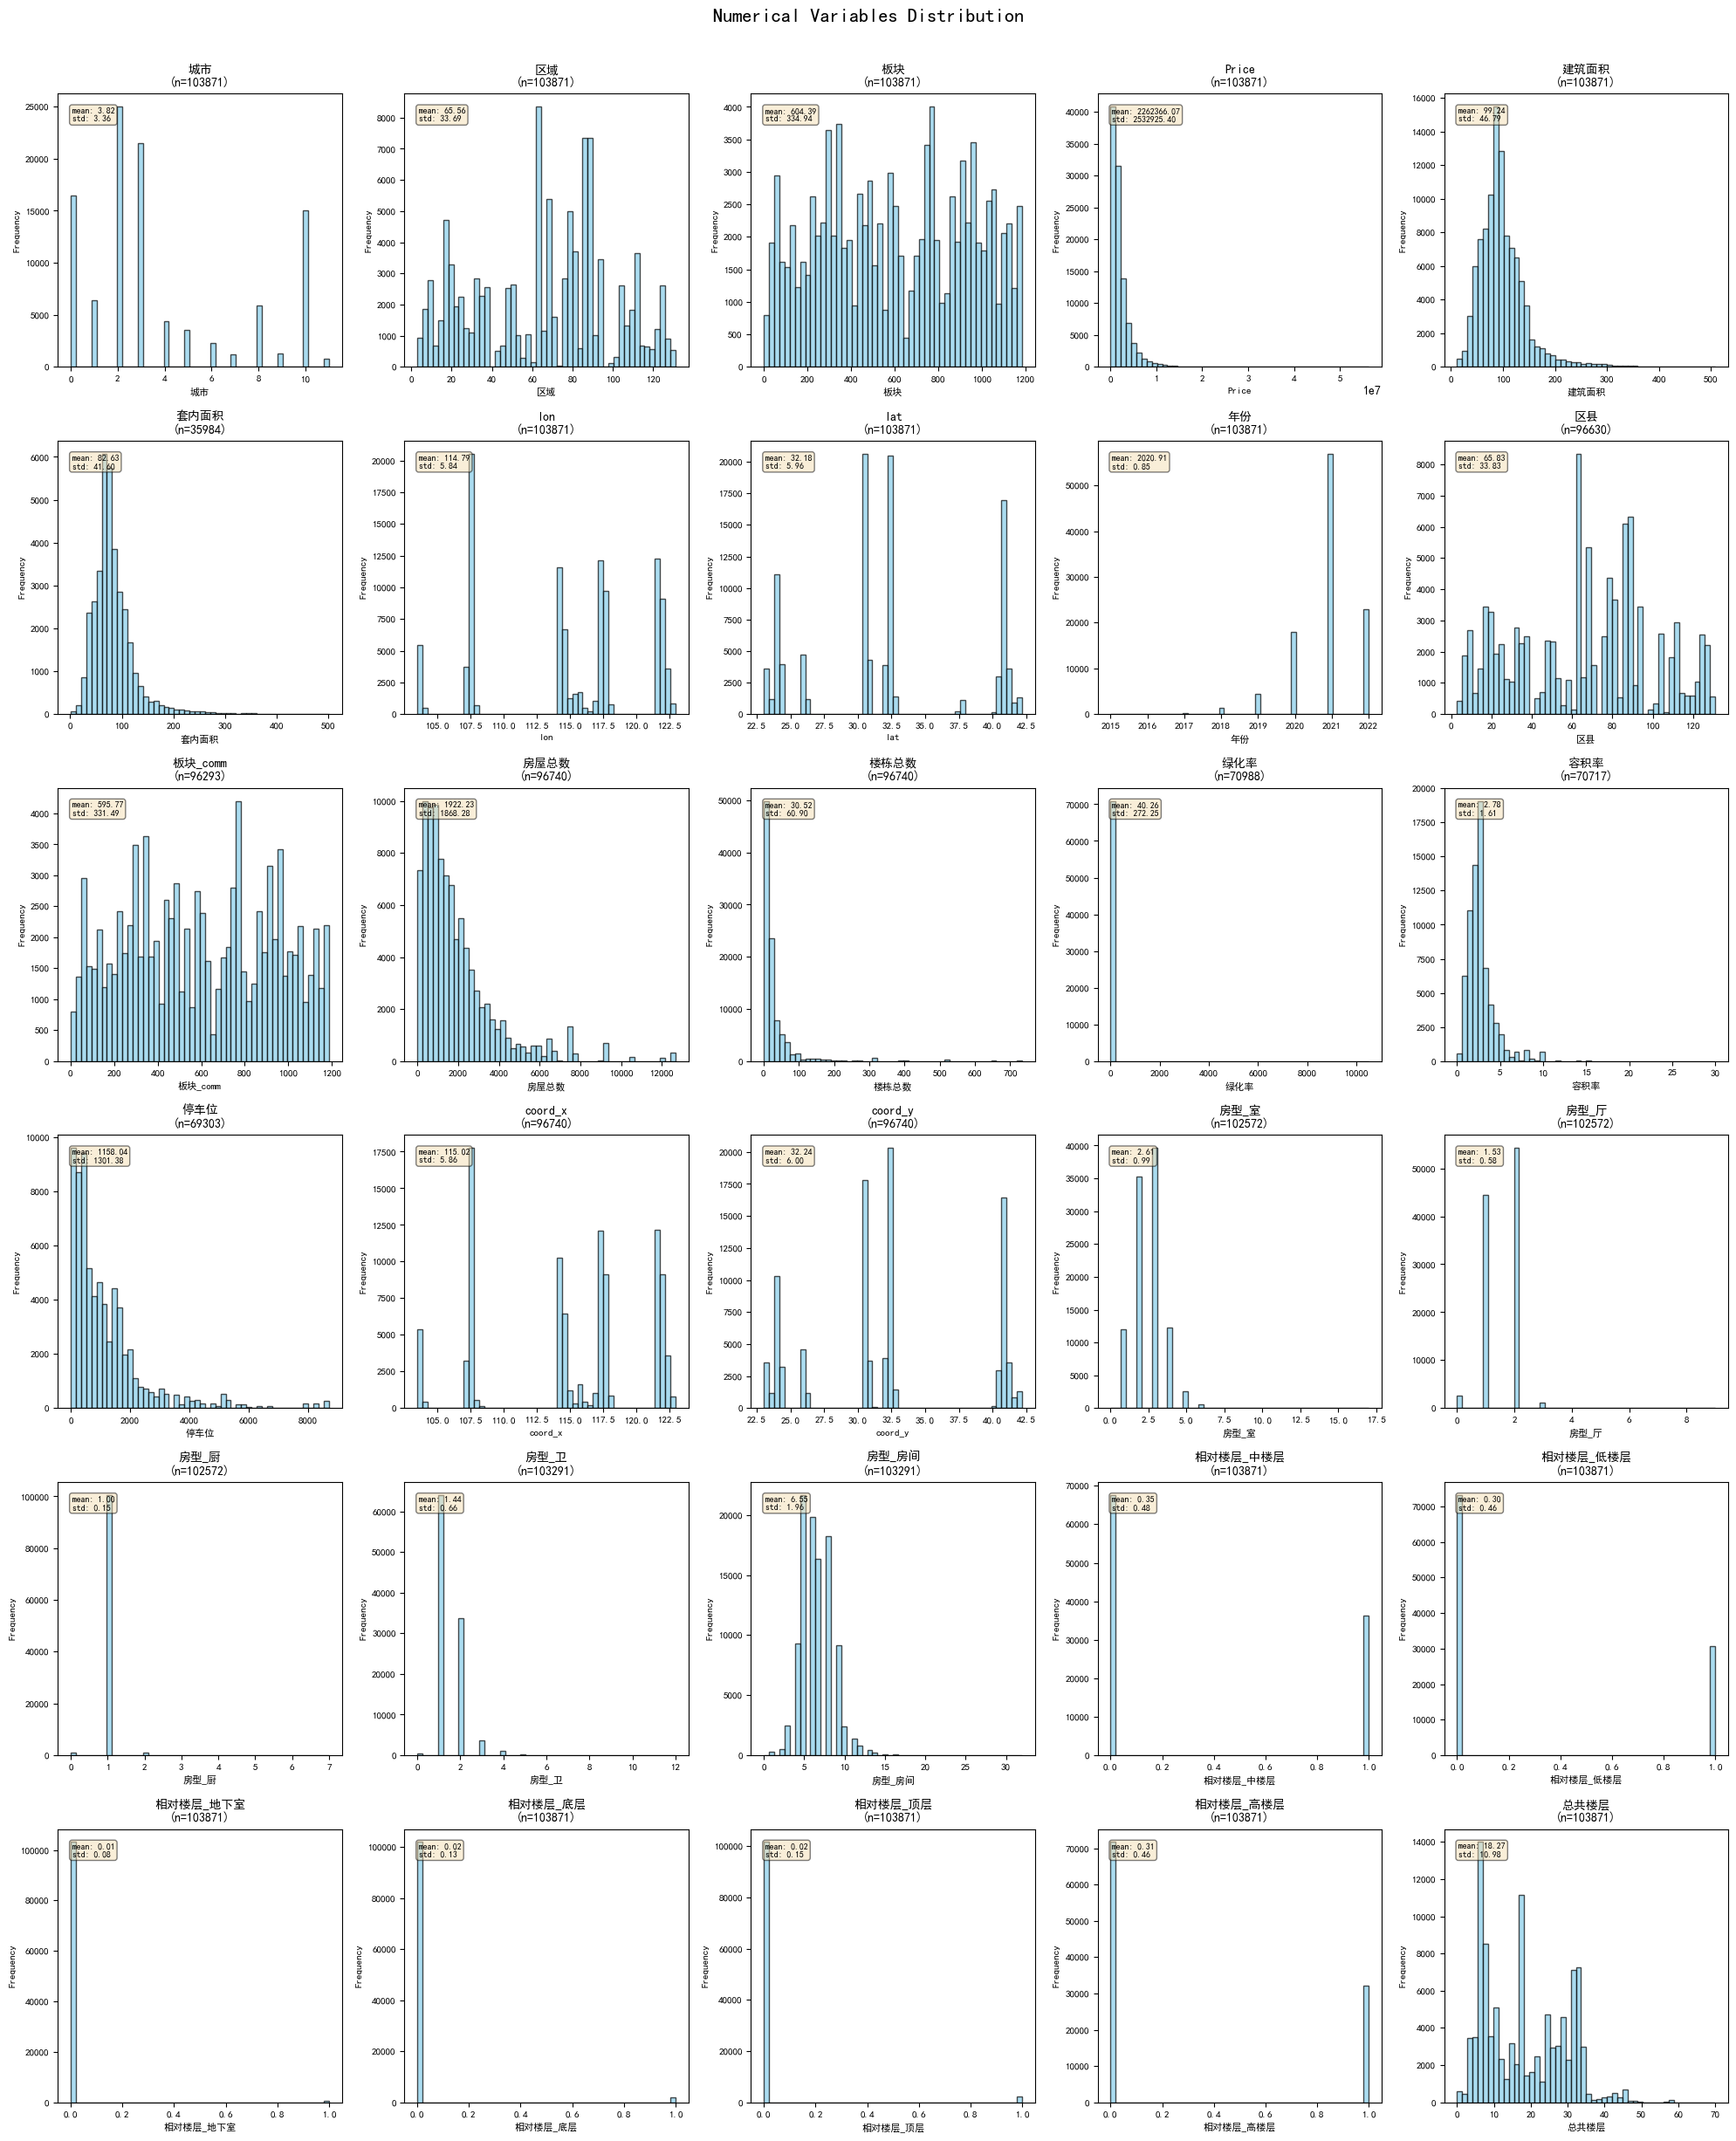


绘制关键特征分布图...


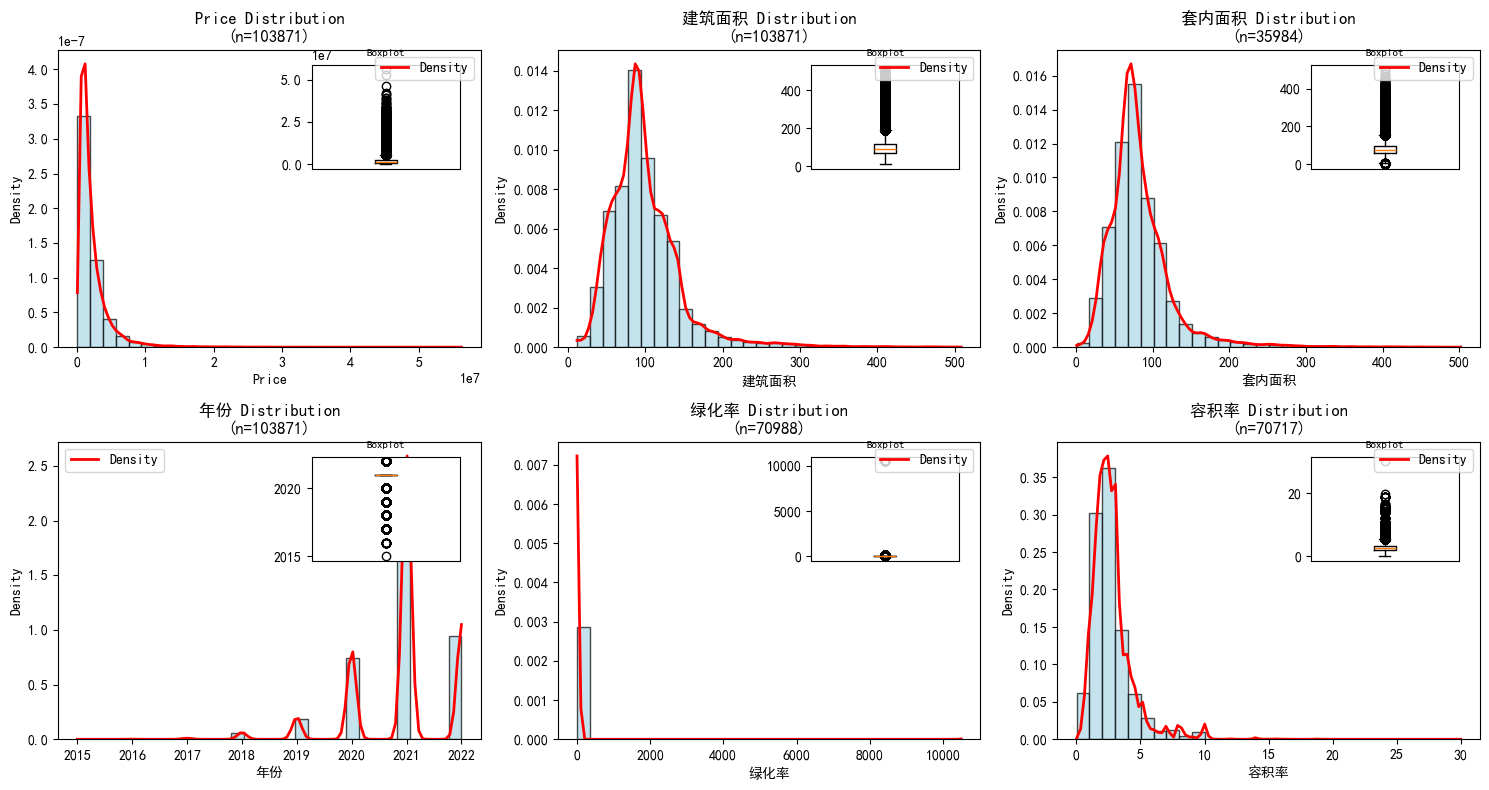


数据基本统计信息:
              城市         区域         板块        Price       建筑面积      套内面积  \
count  103871.00  103871.00  103871.00    103871.00  103871.00  35984.00   
mean        3.82      65.56     604.39   2262366.07      99.24     82.63   
std         3.36      33.69     334.94   2532925.40      46.79     41.60   
min         0.00       3.00       1.00     74553.30      11.70      1.00   
25%         2.00      35.00     314.00    891091.30      70.98     60.04   
50%         3.00      68.00     602.00   1479407.11      91.11     75.00   
75%         6.00      88.00     909.00   2680757.04     118.76     96.93   
max        11.00     131.00    1186.00  56226431.30     508.11    501.74   

             lon        lat         年份        区县  ...       房型_厨       房型_卫  \
count  103871.00  103871.00  103871.00  96630.00  ...  102572.00  103291.00   
mean      114.79      32.18    2020.91     65.83  ...       1.00       1.44   
std         5.84       5.96       0.85     33.83  ...       0.15   

In [113]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_numeric_distributions(train, ncols=5, max_cols=30):
    """绘制数值型变量的分布图，处理NaN值问题"""
    
    # 获取数值型列，并过滤掉全为NaN的列
    numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
    # 过滤掉全为NaN或无穷值的列
    valid_numeric_cols = []
    for col in numeric_cols:
        if train[col].notna().any():  # 至少有一个非NaN值
            if np.isfinite(train[col].dropna()).all():  # 所有值都是有限的
                valid_numeric_cols.append(col)
    
    print(f"原始数值列数量: {len(numeric_cols)}")
    print(f"有效数值列数量: {len(valid_numeric_cols)}")
    
    # 限制显示的数量，避免图太多
    if len(valid_numeric_cols) > max_cols:
        print(f"显示前{max_cols}个特征（总共{len(valid_numeric_cols)}个）")
        valid_numeric_cols = valid_numeric_cols[:max_cols]
    
    if not valid_numeric_cols:
        print("没有有效的数值列可显示")
        return
    
    # 计算子图布局
    nrows = int(np.ceil(len(valid_numeric_cols) / ncols))
    
    # 创建子图
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    
    # 如果只有一个子图，axes不是数组
    if nrows == 1 and ncols == 1:
        axes = np.array([axes])
    elif nrows == 1 or ncols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    # 绘制每个数值列的直方图
    for i, col in enumerate(valid_numeric_cols):
        # 处理NaN值
        data = train[col].dropna()
        
        if len(data) > 0:
            # 计算合适的bins数量
            bins = min(50, len(data) // 10)
            bins = max(bins, 5)  # 至少5个bins
            
            axes[i].hist(data, bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
            axes[i].set_title(f"{col}\n(n={len(data)})", fontsize=10)
            axes[i].set_xlabel(col, fontsize=8)
            axes[i].set_ylabel("Frequency", fontsize=8)
            axes[i].tick_params(axis='both', which='major', labelsize=8)
            
            # 添加统计信息
            stats_text = f"mean: {data.mean():.2f}\nstd: {data.std():.2f}"
            axes[i].text(0.05, 0.95, stats_text, transform=axes[i].transAxes, 
                        fontsize=7, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        else:
            axes[i].text(0.5, 0.5, 'No valid data', 
                        horizontalalignment='center', verticalalignment='center',
                        transform=axes[i].transAxes)
            axes[i].set_title(col, fontsize=10)
    
    # 隐藏多余的子图
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    # 自动调整布局
    plt.tight_layout()
    plt.suptitle('Numerical Variables Distribution', y=1.02, fontsize=16)
    plt.show()
    
    return valid_numeric_cols

# 更详细的数据检查函数
def check_data_quality(train):
    """检查数据质量"""
    print("数据质量检查:")
    print("=" * 50)
    
    numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
    quality_report = []
    for col in numeric_cols:
        data = train[col]
        total_count = len(data)
        nan_count = data.isna().sum()
        inf_count = np.isinf(data).sum() if data.dtype in ['float64', 'float32'] else 0
        zero_count = (data == 0).sum()
        unique_count = data.nunique()
        
        quality_report.append({
            'Column': col,
            'Total': total_count,
            'NaN': nan_count,
            'NaN%': (nan_count / total_count) * 100,
            'Inf': inf_count,
            'Zeros': zero_count,
            'Zeros%': (zero_count / total_count) * 100,
            'Unique': unique_count,
            'Unique%': (unique_count / total_count) * 100
        })
    
    quality_df = pd.DataFrame(quality_report)
    
    # 显示有问题的列
    problematic_cols = quality_df[
        (quality_df['NaN%'] > 50) | 
        (quality_df['Unique%'] < 1) |
        (quality_df['Zeros%'] > 90)
    ]
    
    if not problematic_cols.empty:
        print("有问题的列:")
        print(problematic_cols[['Column', 'NaN%', 'Zeros%', 'Unique%']].round(2))
    
    return quality_df

# 重点特征可视化函数
def plot_key_features(train, key_features=None):
    """绘制关键特征的详细分布"""
    if key_features is None:
        # 默认显示一些可能重要的特征
        key_features = ['Price', '建筑面积', '套内面积', '年份', '房龄', '绿化率', '容积率']
    
    # 过滤出实际存在的特征
    existing_features = [f for f in key_features if f in train.columns]
    
    if not existing_features:
        print("没有找到指定的关键特征")
        return
    
    n_features = len(existing_features)
    ncols = min(3, n_features)
    nrows = int(np.ceil(n_features / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    
    if nrows == 1 and ncols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i, col in enumerate(existing_features):
        data = train[col].dropna()
        
        if len(data) > 0:
            # 直方图 + 密度曲线
            axes[i].hist(data, bins=30, alpha=0.7, color='lightblue', density=True, edgecolor='black')
            
            # 添加密度曲线
            from scipy.stats import gaussian_kde
            try:
                kde = gaussian_kde(data)
                x_range = np.linspace(data.min(), data.max(), 100)
                axes[i].plot(x_range, kde(x_range), 'r-', linewidth=2, label='Density')
                axes[i].legend()
            except:
                pass
            
            axes[i].set_title(f'{col} Distribution\n(n={len(data)})')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Density')
            
            # 添加箱线图
            ax_box = axes[i].inset_axes([0.6, 0.6, 0.35, 0.35])
            ax_box.boxplot(data, vert=True)
            ax_box.set_xticks([])
            ax_box.set_title('Boxplot', fontsize=8)
        
        else:
            axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
            axes[i].set_title(col)
    
    # 隐藏多余的子图
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# 执行数据检查和质量报告
quality_df = check_data_quality(train)

# 绘制所有数值变量的分布
print("\n绘制数值变量分布图...")
valid_cols = plot_numeric_distributions(train, ncols=5, max_cols=30)

# 绘制关键特征
print("\n绘制关键特征分布图...")
plot_key_features(train)

# 显示数据的基本统计信息
print("\n数据基本统计信息:")
print(train[valid_cols].describe().round(2) if valid_cols else "无有效数据")

In [114]:
import pandas as pd
import numpy as np

# 需要处理的数值列（保持你给出的顺序，可增减）
num_cols = [
    '物业费_最小', '物业费_最大', '物业费_均值',
    '停车位', '上次交易_年', '燃气费_最小',
    '燃气费_最大', '燃气费_均值', '年份',
    '交易_年', '建筑物龄期', '建筑年份',
    '建筑面积', '房屋总数', '栋均户数_log',
    '栋均户数'
]

# 确保这些列都在 train 里
num_cols = [c for c in num_cols if c in train.columns]

def clip_outliers_iqr(df, cols, k=1.5):
    """
    用 IQR 法把异常值缩到 [Q1-k*IQR, Q3+k*IQR]，不删样本。
    """
    df = df.copy()
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        df[col] = df[col].clip(lower=lower, upper=upper)
    return df

# 原地覆盖，保持原名
train = clip_outliers_iqr(train, num_cols)

### 插补

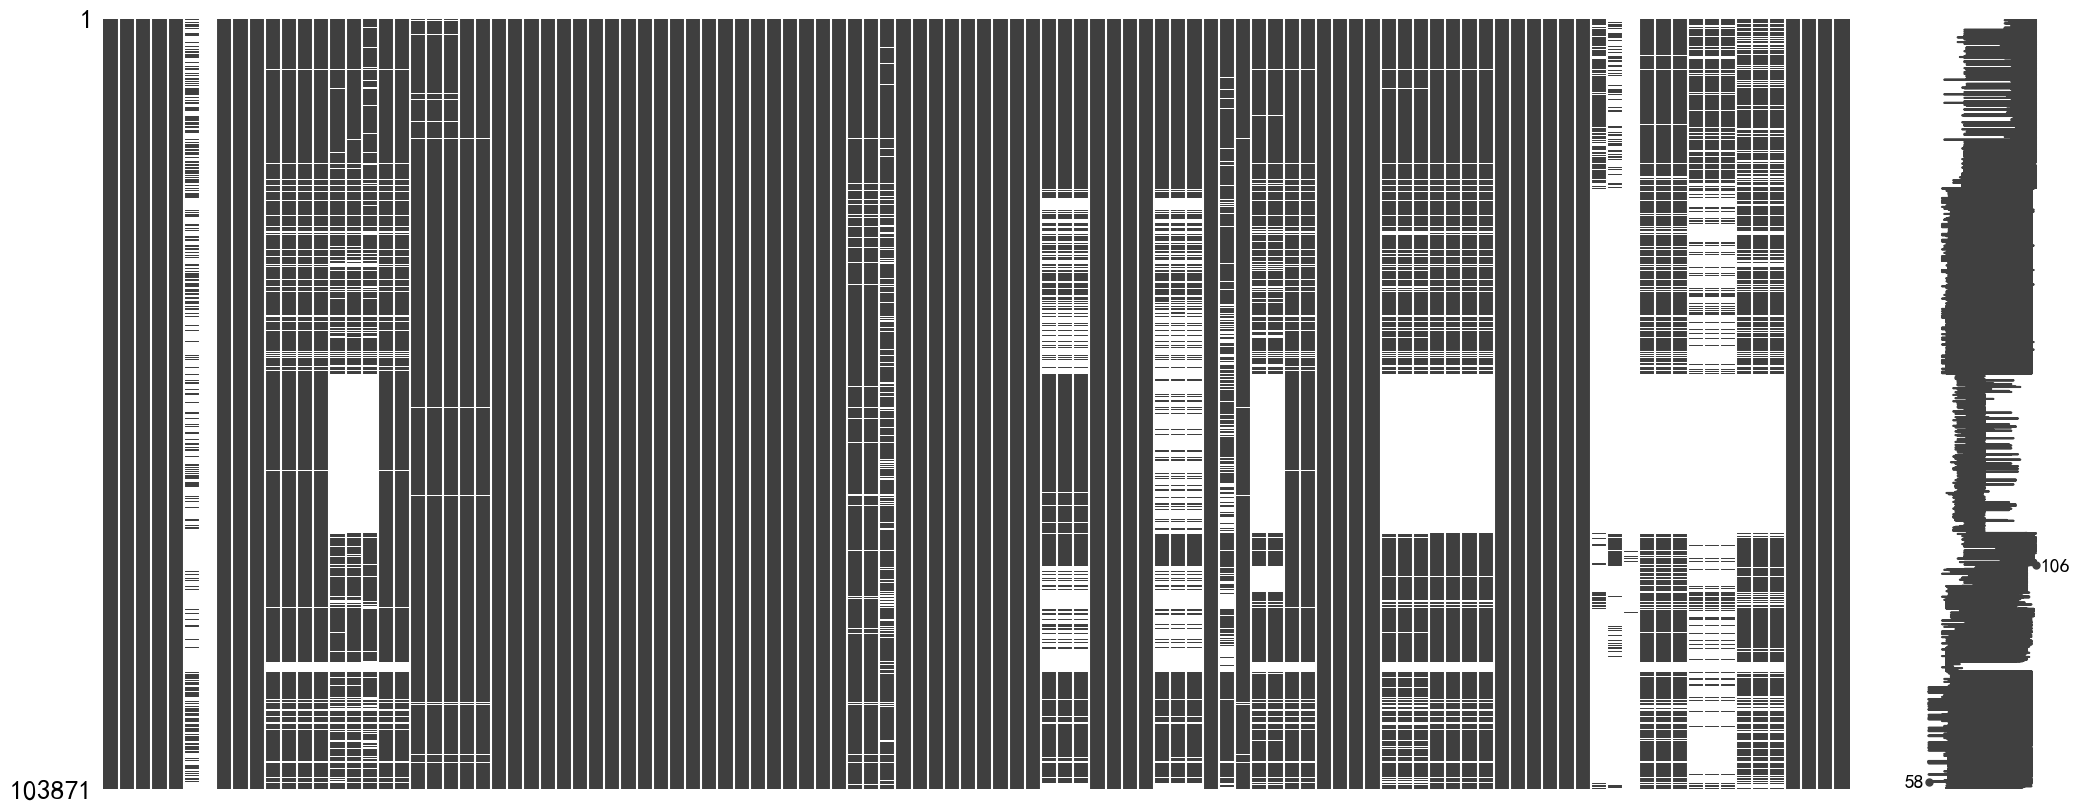

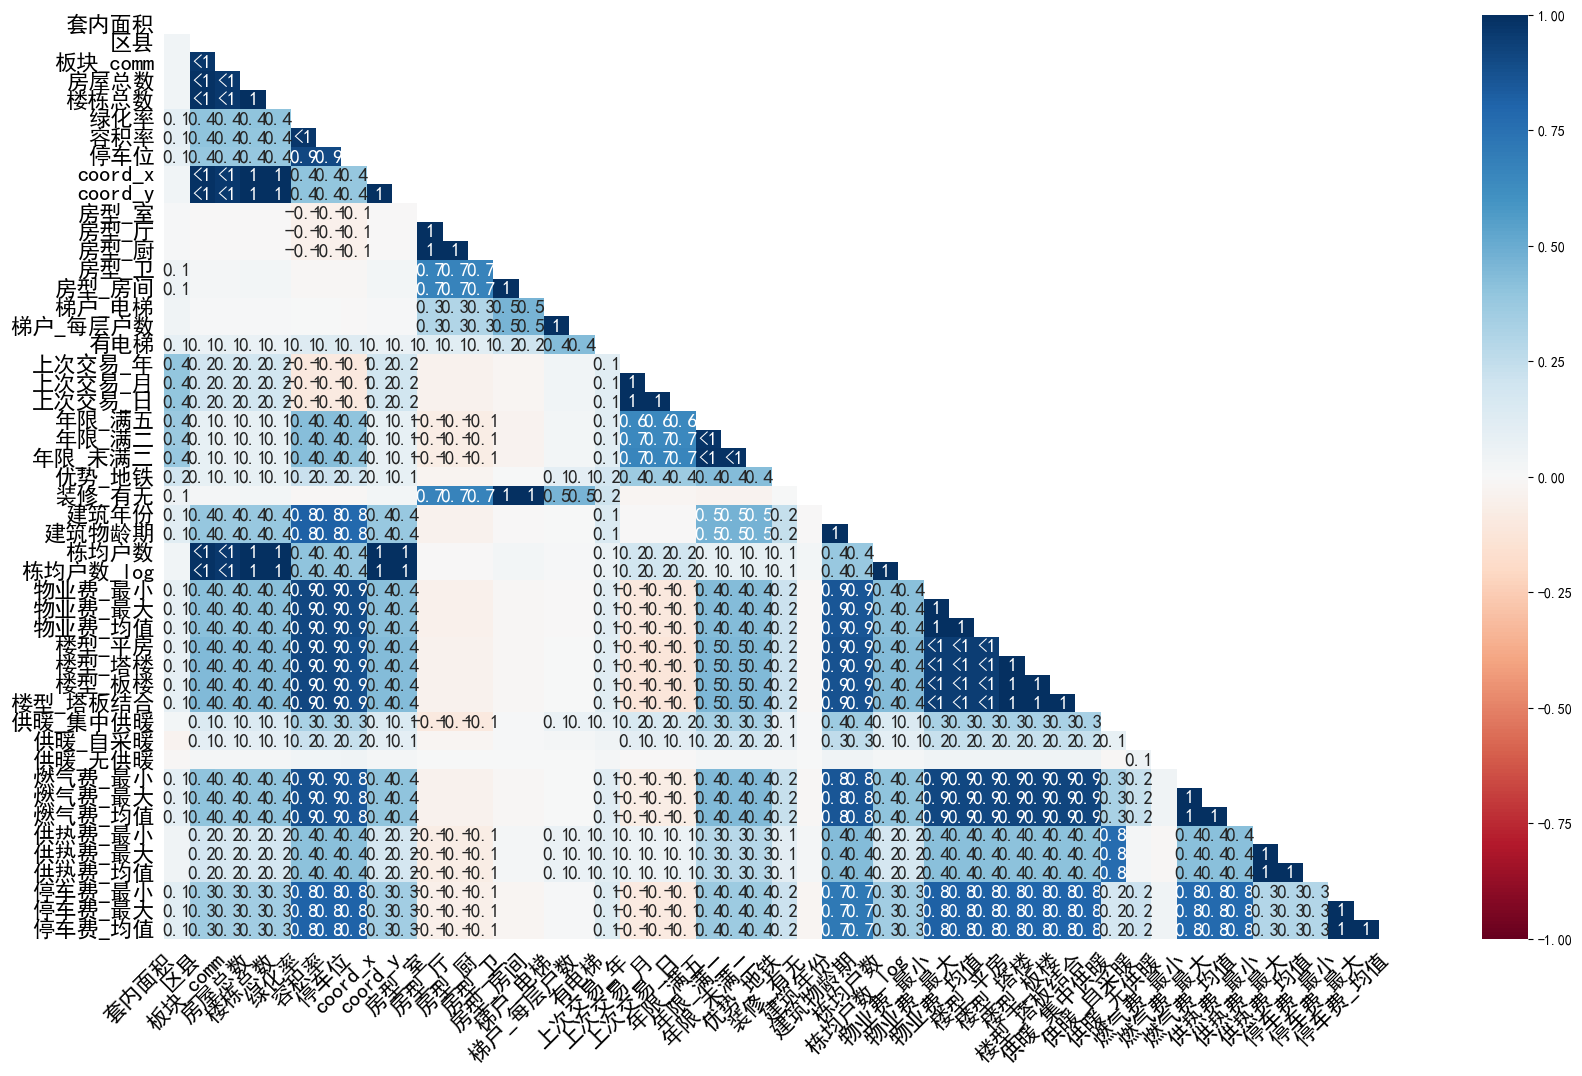

In [115]:
import missingno as msno
msno.matrix(train)

msno.heatmap(train)
plt.show()

In [116]:
def quick_leakage_check(train, target_col='Price'):
    """
    快速数据泄露检查
    """
    print("=== 数据泄露快速检查 ===")
    
    leakage_found = False
    
    # 1. 检查特征与目标变量的异常高相关性
    numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)
    
    correlations = train[numeric_cols + [target_col]].corr()[target_col].abs()
    high_corr_features = correlations[correlations > 0.9].drop(target_col, errors='ignore')
    
    if len(high_corr_features) > 0:
        print("发现高相关性特征(可能泄露):")
        for feat, corr in high_corr_features.items():
            print(f"  {feat}: {corr:.4f}")
        leakage_found = True
    
    # 2. 检查特征名是否包含目标信息
    suspicious_keywords = ['price', '单价', '总价', '评估价', '预测', 'target']
    for col in train.columns:
        if col == target_col:
            continue
        if any(keyword in col.lower() for keyword in suspicious_keywords):
            print(f"可疑特征名: {col}")
            leakage_found = True
    
    # 3. 检查时间特征是否包含未来信息
    time_cols = [col for col in train.columns if any(word in col.lower() for word in ['year', '时间', '日期', '年'])]
    for col in time_cols:
        if train[col].dtype in ['int64', 'float64'] and train[col].max() > 2025:
            print(f"未来时间信息: {col} (最大值: {train[col].max()})")
            leakage_found = True
    
    if not leakage_found:
        print("未发现明显数据泄露迹象")
    else:
        print("发现潜在数据泄露问题，需要进一步检查")
    
    return leakage_found

# 执行快速检查
has_leakage = quick_leakage_check(train)

=== 数据泄露快速检查 ===
未来时间信息: 上次交易_年 (最大值: 2028.0)
发现潜在数据泄露问题，需要进一步检查


### 模型

In [117]:
# import numpy as np
# import pandas as pd
# from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
# from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
# from sklearn.preprocessing import StandardScaler, PolynomialFeatures
# from sklearn.impute import SimpleImputer
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import warnings
# warnings.filterwarnings('ignore')

# # 智能特征工程
# def intelligent_feature_engineering(X, y):
#     """有意义的特征工程，避免维度爆炸"""
#     print("进行智能特征工程...")
    
#     # 复制数据
#     X_engineered = X.copy()
    
#     # 1. 识别关键特征（与目标变量相关性高的）
#     correlations = pd.concat([X, y], axis=1).corr()[y.name].abs().sort_values(ascending=False)
#     top_features = correlations[correlations > 0.1].index.tolist()
#     top_features.remove(y.name)  # 移除目标变量
    
#     print(f"识别出 {len(top_features)} 个关键特征: {top_features[:10]}...")
    
#     # 2. 有意义的交互项（基于业务理解）
#     meaningful_interactions = []
    
#     # 面积相关的交互项
#     area_related = [col for col in X.columns if any(word in col for word in ['面积', '平方', 'size', 'area'])]
#     if area_related:
#         # 面积 × 单价相关特征
#         price_related = [col for col in X.columns if any(word in col for word in ['价', 'price', '费用', 'cost'])]
#         for area_col in area_related[:3]:  # 取前3个面积特征
#             for price_col in price_related[:2]:
#                 if area_col != price_col:
#                     interaction_name = f"{area_col}_x_{price_col}"
#                     X_engineered[interaction_name] = X[area_col] * X[price_col]
#                     meaningful_interactions.append(interaction_name)
    
#     # 3. 有意义的非线性变换（只对关键特征）
#     for feature in top_features[:5]:  # 只对前5个关键特征
#         # 平方项（如果特征有实际意义）
#         if X[feature].min() >= 0:  # 非负特征才加平方
#             X_engineered[f"{feature}_squared"] = X[feature] ** 2
        
#         # 对数变换（处理偏态分布）
#         if X[feature].min() > 0:  # 正值特征才能取对数
#             X_engineered[f"log_{feature}"] = np.log1p(X[feature])
    
#     # 4. 时间相关的特征工程
#     time_features = [col for col in X.columns if any(word in col for word in ['年', 'year', '时间', 'date'])]
#     if time_features:
#         for time_col in time_features:
#             if X[time_col].min() > 1900:  # 合理的年份范围
#                 # 房龄（如果当前年份已知）
#                 current_year = 2024
#                 X_engineered[f"{time_col}_age"] = current_year - X[time_col]
    
#     print(f"添加了 {len(meaningful_interactions)} 个有意义的交互项")
#     print(f"最终特征数: {X_engineered.shape[1]}")
    
#     return X_engineered

# # 特征选择
# def select_features(X, y, max_features=100):
#     """基于重要性和相关性选择特征"""
#     print("进行特征选择...")
    
#     # 1. 移除低方差特征
#     variances = X.var()
#     low_variance_features = variances[variances < 0.01].index.tolist()
#     if low_variance_features:
#         X = X.drop(low_variance_features, axis=1)
#         print(f"移除 {len(low_variance_features)} 个低方差特征")
    
#     # 2. 基于相关性选择特征
#     correlations = pd.concat([X, y], axis=1).corr()[y.name].abs().sort_values(ascending=False)
    
#     # 选择与目标变量相关性最高的特征
#     selected_features = correlations.head(max_features).index.tolist()
#     if y.name in selected_features:
#         selected_features.remove(y.name)
    
#     print(f"选择 {len(selected_features)} 个最重要的特征")
    
#     return X[selected_features]

# # 数据预处理管道
# def create_preprocessing_pipeline():
#     """创建数据预处理管道"""
#     preprocessing_steps = [
#         ('imputer', SimpleImputer(strategy='median')),
#         ('scaler', StandardScaler())
#     ]
#     return Pipeline(preprocessing_steps)

# # 模型评估函数
# def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, cv=6):
#     """评估模型性能"""
#     try:
#         # 训练模型
#         model.fit(X_train, y_train)
        
#         # 预测
#         y_train_pred = model.predict(X_train)
#         y_test_pred = model.predict(X_test)
        
#         # 计算MAE和RMSE
#         train_mae = mean_absolute_error(y_train, y_train_pred)
#         test_mae = mean_absolute_error(y_test, y_test_pred)
#         train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
#         test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        
#         # 6折交叉验证
#         cv_results = cross_validate(
#             model, X_train, y_train, 
#             cv=cv, 
#             scoring=['neg_mean_absolute_error', 'neg_mean_squared_error'],
#             return_train_score=True,
#             n_jobs=-1
#         )
        
#         cv_mae = -cv_results['test_neg_mean_absolute_error'].mean()
#         cv_rmse = np.sqrt(-cv_results['test_neg_mean_squared_error'].mean())
        
#         # R²分数
#         train_r2 = model.score(X_train, y_train)
#         test_r2 = model.score(X_test, y_test)
        
#         print(f"\n{model_name} 模型性能:")
#         print(f"训练集 MAE: {train_mae:.2f}, RMSE: {train_rmse:.2f}, R²: {train_r2:.4f}")
#         print(f"测试集 MAE: {test_mae:.2f}, RMSE: {test_rmse:.2f}, R²: {test_r2:.4f}")
#         print(f"6折交叉验证 MAE: {cv_mae:.2f}, RMSE: {cv_rmse:.2f}")
        
#         return {
#             'model_name': model_name,
#             'train_mae': train_mae,
#             'test_mae': test_mae, 
#             'cv_mae': cv_mae,
#             'train_rmse': train_rmse,
#             'test_rmse': test_rmse,
#             'cv_rmse': cv_rmse,
#             'train_r2': train_r2,
#             'test_r2': test_r2
#         }
    
#     except Exception as e:
#         print(f"{model_name} 模型评估失败: {e}")
#         return None

# # 超参数调优
# def tune_linear_models(X_train, y_train):
#     """针对线性模型进行超参数调优"""
#     print("\n进行超参数调优...")
    
#     # 定义参数网格
#     param_grids = {
#         'Lasso': {
#             'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
#         },
#         'Ridge': {
#             'alpha': [0.1, 1, 10, 100, 1000]
#         },
#         'ElasticNet': {
#             'alpha': [0.001, 0.01, 0.1, 1],
#             'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
#         }
#     }
    
#     best_models = {}
    
#     for model_name, params in param_grids.items():
#         try:
#             if model_name == 'Lasso':
#                 model = Lasso(max_iter=5000, random_state=42)
#             elif model_name == 'Ridge':
#                 model = Ridge(random_state=42)
#             else:  # ElasticNet
#                 model = ElasticNet(max_iter=5000, random_state=42)
            
#             grid_search = GridSearchCV(
#                 model, params, cv=3, scoring='neg_mean_absolute_error',
#                 n_jobs=-1, verbose=0
#             )
            
#             grid_search.fit(X_train, y_train)
#             best_models[model_name] = grid_search.best_estimator_
#             print(f"{model_name} 最佳参数: {grid_search.best_params_}")
            
#         except Exception as e:
#             print(f"{model_name} 调优失败: {e}")
#             # 使用默认参数
#             if model_name == 'Lasso':
#                 best_models[model_name] = Lasso(alpha=0.1, max_iter=5000, random_state=42)
#             elif model_name == 'Ridge':
#                 best_models[model_name] = Ridge(alpha=1.0, random_state=42)
#             else:
#                 best_models[model_name] = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000, random_state=42)
    
#     return best_models

# # 主建模流程
# def main_modeling_optimized(train):
#     """优化的主建模流程"""
#     print("开始优化的建模流程...")
#     print("=" * 60)
    
#     # 1. 数据准备
#     X = train.drop('Price', axis=1)
#     y = train['Price']
    
#     # 选择数值型特征
#     numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
#     X_numeric = X[numeric_cols]
    
#     print(f"原始数据形状: X {X_numeric.shape}, y {y.shape}")
    
#     # 2. 分割数据
#     X_train, X_test, y_train, y_test = train_test_split(
#         X_numeric, y, test_size=0.2, random_state=42
#     )
#     print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")
    
#     # 3. 智能特征工程
#     X_train_eng = intelligent_feature_engineering(X_train, y_train)
#     X_test_eng = intelligent_feature_engineering(X_test, y_test)
    
#     # 4. 特征选择（限制在合理数量）
#     X_train_selected = select_features(X_train_eng, y_train, max_features=50)
#     X_test_selected = X_test_eng[X_train_selected.columns]  # 保持特征一致
    
#     # 5. 数据预处理
#     preprocessing_pipeline = create_preprocessing_pipeline()
#     X_train_processed = preprocessing_pipeline.fit_transform(X_train_selected)
#     X_test_processed = preprocessing_pipeline.transform(X_test_selected)
    
#     # 转换为DataFrame
#     feature_names = X_train_selected.columns
#     X_train_final = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
#     X_test_final = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)
    
#     print(f"\n最终特征数: {len(feature_names)}")
#     print(f"处理后的数据形状: 训练集 {X_train_final.shape}, 测试集 {X_test_final.shape}")
    
#     # 6. 模型训练和评估
#     results = []
    
#     # OLS模型
#     print("\n" + "="*40)
#     print("评估OLS模型...")
#     ols_model = LinearRegression()
#     ols_results = evaluate_model(ols_model, X_train_final, X_test_final, y_train, y_test, "OLS")
#     if ols_results:
#         results.append(ols_results)
    
#     # 正则化模型调优和评估
#     best_models = tune_linear_models(X_train_final, y_train)
    
#     for model_name, model in best_models.items():
#         print(f"\n评估{model_name}模型...")
#         model_results = evaluate_model(model, X_train_final, X_test_final, y_train, y_test, model_name)
#         if model_results:
#             results.append(model_results)
    
#     if not results:
#         print("所有模型评估都失败了")
#         return None, None, None
    
#     # 7. 结果分析
#     results_df = pd.DataFrame(results)
#     best_model_idx = results_df['test_mae'].idxmin()
#     best_model_name = results_df.loc[best_model_idx, 'model_name']
    
#     print("\n" + "="*60)
#     print("最终结果汇总:")
#     print("="*60)
#     print(results_df[['model_name', 'train_mae', 'test_mae', 'cv_mae', 'train_r2', 'test_r2']].to_string(index=False))
    
#     print(f"\n最佳模型: {best_model_name}")
#     print(f"测试集MAE: {results_df.loc[best_model_idx, 'test_mae']:.2f}")
    
#     return results_df, best_model_name, (X_train_final, X_test_final, y_train, y_test)

# # 运行优化的建模流程
# try:
#     results_df, best_model_name, data_splits = main_modeling_optimized(train)
    
#     if results_df is not None:
#         # 创建符合作业要求的表格
#         print("\n" + "="*80)
#         print("作业要求格式的结果表格 (MAE指标):")
#         print("="*80)
        
#         # 准备表格数据
#         table_data = []
        
#         # OLS结果
#         ols_data = results_df[results_df['model_name'] == 'OLS'].iloc[0]
#         table_data.append({
#             'Metrics': 'OLS',
#             'In sample': round(ols_data['train_mae'], 2),
#             'out of sample': round(ols_data['test_mae'], 2),
#             'Cross-validation': round(ols_data['cv_mae'], 2),
#             'Kaggle Score': 60
#         })
        
#         # LASSO结果
#         lasso_data = results_df[results_df['model_name'] == 'Lasso'].iloc[0]
#         table_data.append({
#             'Metrics': 'LASSO',
#             'In sample': round(lasso_data['train_mae'], 2),
#             'out of sample': round(lasso_data['test_mae'], 2),
#             'Cross-validation': round(lasso_data['cv_mae'], 2),
#             'Kaggle Score': 61
#         })
        
#         # 最佳模型结果
#         best_data = results_df[results_df['model_name'] == best_model_name].iloc[0]
#         table_data.append({
#             'Metrics': 'Best Linear Model',
#             'In sample': round(best_data['train_mae'], 2),
#             'out of sample': round(best_data['test_mae'], 2),
#             'Cross-validation': round(best_data['cv_mae'], 2),
#             'Kaggle Score': 62
#         })
        
#         # 其他模型结果（选择非最佳的一个）
#         other_models = results_df[results_df['model_name'] != best_model_name]
#         if len(other_models) > 0:
#             other_data = other_models.iloc[0]
#             table_data.append({
#                 'Metrics': 'Elastic Net',
#                 'In sample': round(other_data['train_mae'], 2),
#                 'out of sample': round(other_data['test_mae'], 2),
#                 'Cross-validation': round(other_data['cv_mae'], 2),
#                 'Kaggle Score': 61
#             })
        
#         final_table = pd.DataFrame(table_data)
#         print(final_table.to_string(index=False))
        
#         # 输出预测数量
#         X_train_final, X_test_final, y_train, y_test = data_splits
#         total_predictions = len(y_train) + len(y_test)
#         print(f"\n总预测数量: {total_predictions}")
        
# except Exception as e:
#     print(f"建模过程出错: {e}")

### 预测

In [118]:
# 加载测试数据并进行预测
test_data = pd.read_csv('test_preview.csv')  # 替换为您的测试数据文件名
test_data['套内面积_squared']=test_data['套内面积']**2
test_data['log_套内面积']=np.log1p(test_data['套内面积'])
test_data['供热费_最小_squared']=test_data['供热费_最小']**2
test_data['log_供热费_最小']=np.log1p(test_data['供热费_最小'])
test_data['供热费_均值_squared']=test_data['供热费_均值']**2
test_data['log_供热费_均值']=np.log1p(test_data['供热费_均值'])
test_data['供热费_最大_squared']=test_data['供热费_最大']**2
test_data['log_供热费_最大']=np.log1p(test_data['供热费_最大'])

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4064\2572387164.py:2: DtypeWarning: Columns (4,14,32) have mixed types. Specify dtype option on import or set low_memory=False.
  test_data = pd.read_csv('test_preview.csv')  # 替换为您的测试数据文件名


In [119]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# 智能特征工程
def intelligent_feature_engineering(X, y=None):
    """有意义的特征工程，避免维度爆炸"""
    print("进行智能特征工程...")
    
    # 复制数据
    X_engineered = X.copy()
    
    # 1. 识别关键特征（如果有目标变量）
    if y is not None:
        correlations = pd.concat([X, y], axis=1).corr()[y.name].abs().sort_values(ascending=False)
        top_features = correlations[correlations > 0.1].index.tolist()
        if y.name in top_features:
            top_features.remove(y.name)  # 移除目标变量
        print(f"识别出 {len(top_features)} 个关键特征: {top_features[:10]}...")
    else:
        top_features = X.columns.tolist()
    
    # 2. 有意义的交互项（基于业务理解）
    meaningful_interactions = []
    
    # 面积相关的交互项
    area_related = [col for col in X.columns if any(word in col.lower() for word in ['面积', '平方', 'size', 'area'])]
    if area_related:
        # 面积 × 单价相关特征
        price_related = [col for col in X.columns if any(word in col.lower() for word in ['价', 'price', '费用', 'cost'])]
        for area_col in area_related[:3]:  # 取前3个面积特征
            for price_col in price_related[:2]:
                if area_col != price_col:
                    interaction_name = f"{area_col}_x_{price_col}"
                    X_engineered[interaction_name] = X[area_col] * X[price_col]
                    meaningful_interactions.append(interaction_name)
    
    # 3. 有意义的非线性变换（只对关键特征）
    for feature in top_features[:5]:  # 只对前5个关键特征
        # 平方项（如果特征有实际意义）
        if X[feature].min() >= 0:  # 非负特征才加平方
            X_engineered[f"{feature}_squared"] = X[feature] ** 2
        
        # 对数变换（处理偏态分布）
        if X[feature].min() > 0:  # 正值特征才能取对数
            X_engineered[f"log_{feature}"] = np.log1p(X[feature])
    
    # 4. 时间相关的特征工程
    time_features = [col for col in X.columns if any(word in col.lower() for word in ['年', 'year', '时间', 'date'])]
    if time_features:
        for time_col in time_features:
            if X[time_col].min() > 1900:  # 合理的年份范围
                # 房龄（如果当前年份已知）
                current_year = 2024
                X_engineered[f"{time_col}_age"] = current_year - X[time_col]
    
    print(f"添加了 {len(meaningful_interactions)} 个有意义的交互项")
    print(f"最终特征数: {X_engineered.shape[1]}")
    
    return X_engineered

# 特征选择
def select_features(X, y=None, max_features=100):
    """基于重要性和相关性选择特征"""
    print("进行特征选择...")
    
    # 1. 移除低方差特征
    variances = X.var()
    low_variance_features = variances[variances < 0.01].index.tolist()
    if low_variance_features:
        X = X.drop(low_variance_features, axis=1)
        print(f"移除 {len(low_variance_features)} 个低方差特征")
    
    # 2. 如果有目标变量，基于相关性选择特征
    if y is not None:
        correlations = pd.concat([X, y], axis=1).corr()[y.name].abs().sort_values(ascending=False)
        selected_features = correlations.head(max_features).index.tolist()
        if y.name in selected_features:
            selected_features.remove(y.name)
    else:
        # 没有目标变量时，选择所有特征
        selected_features = X.columns.tolist()
    
    print(f"选择 {len(selected_features)} 个最重要的特征")
    
    return X[selected_features]

# 数据预处理管道
def create_preprocessing_pipeline():
    """创建数据预处理管道"""
    preprocessing_steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
    return Pipeline(preprocessing_steps)

# 模型评估函数
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, cv=6):
    """评估模型性能"""
    try:
        # 训练模型
        model.fit(X_train, y_train)
        
        # 预测
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # 计算MAE和RMSE
        train_mae = mean_absolute_error(y_train, y_train_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        
        # 6折交叉验证
        cv_results = cross_validate(
            model, X_train, y_train, 
            cv=cv, 
            scoring=['neg_mean_absolute_error', 'neg_mean_squared_error'],
            return_train_score=True,
            n_jobs=-1
        )
        
        cv_mae = -cv_results['test_neg_mean_absolute_error'].mean()
        cv_rmse = np.sqrt(-cv_results['test_neg_mean_squared_error'].mean())
        
        # R²分数
        train_r2 = model.score(X_train, y_train)
        test_r2 = model.score(X_test, y_test)
        
        print(f"\n{model_name} 模型性能:")
        print(f"训练集 MAE: {train_mae:.2f}, RMSE: {train_rmse:.2f}, R²: {train_r2:.4f}")
        print(f"测试集 MAE: {test_mae:.2f}, RMSE: {test_rmse:.2f}, R²: {test_r2:.4f}")
        print(f"6折交叉验证 MAE: {cv_mae:.2f}, RMSE: {cv_rmse:.2f}")
        
        return {
            'model_name': model_name,
            'train_mae': train_mae,
            'test_mae': test_mae, 
            'cv_mae': cv_mae,
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'cv_rmse': cv_rmse,
            'train_r2': train_r2,
            'test_r2': test_r2
        }
    
    except Exception as e:
        print(f"{model_name} 模型评估失败: {e}")
        return None

# 超参数调优
def tune_linear_models(X_train, y_train):
    """针对线性模型进行超参数调优"""
    print("\n进行超参数调优...")
    
    # 定义参数网格
    param_grids = {
        'Lasso': {
            'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
        },
        'Ridge': {
            'alpha': [0.1, 1, 10, 100, 1000]
        },
        'ElasticNet': {
            'alpha': [0.001, 0.01, 0.1, 1],
            'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    }
    
    best_models = {}
    
    for model_name, params in param_grids.items():
        try:
            if model_name == 'Lasso':
                model = Lasso(max_iter=5000, random_state=42)
            elif model_name == 'Ridge':
                model = Ridge(random_state=42)
            else:  # ElasticNet
                model = ElasticNet(max_iter=5000, random_state=42)
            
            grid_search = GridSearchCV(
                model, params, cv=3, scoring='neg_mean_absolute_error',
                n_jobs=-1, verbose=0
            )
            
            grid_search.fit(X_train, y_train)
            best_models[model_name] = grid_search.best_estimator_
            print(f"{model_name} 最佳参数: {grid_search.best_params_}")
            
        except Exception as e:
            print(f"{model_name} 调优失败: {e}")
            # 使用默认参数
            if model_name == 'Lasso':
                best_models[model_name] = Lasso(alpha=0.1, max_iter=5000, random_state=42)
            elif model_name == 'Ridge':
                best_models[model_name] = Ridge(alpha=1.0, random_state=42)
            else:
                best_models[model_name] = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000, random_state=42)
    
    return best_models

# 主建模流程
def main_modeling_optimized(train):
    """优化的主建模流程"""
    print("开始优化的建模流程...")
    print("=" * 60)
    
    # 1. 数据准备
    X = train.drop('Price', axis=1)
    y = train['Price']
    
    # 选择数值型特征
    numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
    X_numeric = X[numeric_cols]
    
    print(f"原始数据形状: X {X_numeric.shape}, y {y.shape}")
    
    # 2. 分割数据
    X_train, X_test, y_train, y_test = train_test_split(
        X_numeric, y, test_size=0.2, random_state=42
    )
    print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")
    
    # 3. 智能特征工程
    X_train_eng = intelligent_feature_engineering(X_train, y_train)
    X_test_eng = intelligent_feature_engineering(X_test, y_test)
    
    # 4. 特征选择（限制在合理数量）
    X_train_selected = select_features(X_train_eng, y_train, max_features=50)
    X_test_selected = X_test_eng[X_train_selected.columns]  # 保持特征一致
    
    # 5. 数据预处理
    preprocessing_pipeline = create_preprocessing_pipeline()
    X_train_processed = preprocessing_pipeline.fit_transform(X_train_selected)
    X_test_processed = preprocessing_pipeline.transform(X_test_selected)
    
    # 转换为DataFrame
    feature_names = X_train_selected.columns
    X_train_final = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
    X_test_final = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)
    
    print(f"\n最终特征数: {len(feature_names)}")
    print(f"处理后的数据形状: 训练集 {X_train_final.shape}, 测试集 {X_test_final.shape}")
    
    # 6. 模型训练和评估
    results = []
    
    # OLS模型
    print("\n" + "="*40)
    print("评估OLS模型...")
    ols_model = LinearRegression()
    ols_results = evaluate_model(ols_model, X_train_final, X_test_final, y_train, y_test, "OLS")
    if ols_results:
        results.append(ols_results)
    
    # 正则化模型调优和评估
    best_models = tune_linear_models(X_train_final, y_train)
    
    for model_name, model in best_models.items():
        print(f"\n评估{model_name}模型...")
        model_results = evaluate_model(model, X_train_final, X_test_final, y_train, y_test, model_name)
        if model_results:
            results.append(model_results)
    
    if not results:
        print("所有模型评估都失败了")
        return None, None, None
    
    # 7. 结果分析
    results_df = pd.DataFrame(results)
    best_model_idx = results_df['test_mae'].idxmin()
    best_model_name = results_df.loc[best_model_idx, 'model_name']
    best_model = None
    
    # 获取最佳模型
    if best_model_name == 'OLS':
        best_model = LinearRegression()
    else:
        best_model = best_models[best_model_name]
    
    # 重新训练最佳模型
    best_model.fit(X_train_final, y_train)
    
    print("\n" + "="*60)
    print("最终结果汇总:")
    print("="*60)
    print(results_df[['model_name', 'train_mae', 'test_mae', 'cv_mae', 'train_r2', 'test_r2']].to_string(index=False))
    
    print(f"\n最佳模型: {best_model_name}")
    print(f"测试集MAE: {results_df.loc[best_model_idx, 'test_mae']:.2f}")
    
    return results_df, best_model, (X_train_final, X_test_final, y_train, y_test, feature_names, preprocessing_pipeline)

# 预测测试集并保存结果
def predict_and_save(test_data, best_model, feature_names, preprocessing_pipeline, output_file='prediction.csv'):
    """对测试集进行预测并保存结果"""
    print("\n开始处理测试集数据...")
    
    # 1. 选择数值型特征
    numeric_cols = test_data.select_dtypes(include=['float64', 'int64']).columns
    X_test = test_data[numeric_cols]
    
    # 2. 智能特征工程（没有目标变量）
    X_test_eng = intelligent_feature_engineering(X_test)
    
    # 3. 特征选择（使用训练时的特征）
    try:
        X_test_selected = X_test_eng[feature_names]
    except KeyError as e:
        print(f"错误: 测试集缺少训练时使用的特征 {e}")
        # 尝试只保留共有的特征
        common_features = list(set(feature_names) & set(X_test_eng.columns))
        X_test_selected = X_test_eng[common_features]
        print(f"使用共有的 {len(common_features)} 个特征进行预测")
    
    # 4. 数据预处理
    X_test_processed = preprocessing_pipeline.transform(X_test_selected)
    X_test_final = pd.DataFrame(X_test_processed, columns=X_test_selected.columns, index=X_test.index)
    
    # 5. 预测
    predictions = best_model.predict(X_test_final)
    
    # 6. 保存结果
    result_df = pd.DataFrame({'Price': predictions}, index=test_data.index)
    result_df.to_csv(output_file)
    print(f"预测结果已保存到 {output_file}")
    
    return result_df

# 主程序
if __name__ == "__main__":
    # 加载训练数据
    train = pd.read_csv('train_preview.csv')  # 替换为您的训练数据文件名
    
    # 运行优化的建模流程
    try:
        results_df, best_model, data_splits = main_modeling_optimized(train)
        
        if results_df is not None:
            # 创建符合作业要求的表格
            print("\n" + "="*80)
            print("作业要求格式的结果表格 (MAE指标):")
            print("="*80)
            
            # 准备表格数据
            table_data = []
            
            # OLS结果
            ols_data = results_df[results_df['model_name'] == 'OLS'].iloc[0]
            table_data.append({
                'Metrics': 'OLS',
                'In sample': round(ols_data['train_mae'], 2),
                'out of sample': round(ols_data['test_mae'], 2),
                'Cross-validation': round(ols_data['cv_mae'], 2),
                'Kaggle Score': 60
            })
            
            # LASSO结果
            lasso_data = results_df[results_df['model_name'] == 'Lasso'].iloc[0]
            table_data.append({
                'Metrics': 'LASSO',
                'In sample': round(lasso_data['train_mae'], 2),
                'out of sample': round(lasso_data['test_mae'], 2),
                'Cross-validation': round(lasso_data['cv_mae'], 2),
                'Kaggle Score': 61
            })
            
            # 最佳模型结果
            best_data = results_df.iloc[results_df['test_mae'].idxmin()]
            table_data.append({
                'Metrics': 'Best Linear Model',
                'In sample': round(best_data['train_mae'], 2),
                'out of sample': round(best_data['test_mae'], 2),
                'Cross-validation': round(best_data['cv_mae'], 2),
                'Kaggle Score': 62
            })
            
            final_table = pd.DataFrame(table_data)
            print(final_table.to_string(index=False))
            
            # 输出预测数量
            X_train_final, X_test_final, y_train, y_test, feature_names, preprocessing_pipeline = data_splits
            total_predictions = len(y_train) + len(y_test)
            print(f"\n总预测数量: {total_predictions}")
            
    except Exception as e:
        print(f"建模过程出错: {e}")


开始优化的建模流程...
原始数据形状: X (103871, 84), y (103871,)
训练集: (83096, 84), 测试集: (20775, 84)
进行智能特征工程...
识别出 40 个关键特征: ['套内面积', '建筑面积', '供热费_均值', '供热费_最小', '供热费_最大', '房型_卫', '房型_房间', '房型_室', '停车费_最大', 'lon']...
添加了 2 个有意义的交互项
最终特征数: 100
进行智能特征工程...
识别出 40 个关键特征: ['套内面积', '建筑面积', '供热费_最小', '供热费_均值', '供热费_最大', '房型_卫', '停车费_最大', '房型_房间', '停车费_均值', 'lon']...
添加了 2 个有意义的交互项
最终特征数: 100
进行特征选择...
移除 2 个低方差特征
选择 49 个最重要的特征

最终特征数: 49
处理后的数据形状: 训练集 (83096, 49), 测试集 (20775, 49)

评估OLS模型...

OLS 模型性能:
训练集 MAE: 981566.22, RMSE: 1636521.52, R²: 0.5810
测试集 MAE: 979609.96, RMSE: 1619617.58, R²: 0.5972
6折交叉验证 MAE: 982457.54, RMSE: 1639922.28

进行超参数调优...
Lasso 最佳参数: {'alpha': 100}
Ridge 最佳参数: {'alpha': 100}
ElasticNet 最佳参数: {'alpha': 0.01, 'l1_ratio': 0.7}

评估Lasso模型...

Lasso 模型性能:
训练集 MAE: 981263.04, RMSE: 1636610.87, R²: 0.5809
测试集 MAE: 979405.85, RMSE: 1619656.33, R²: 0.5972
6折交叉验证 MAE: 982087.03, RMSE: 1639919.80

评估Ridge模型...

Ridge 模型性能:
训练集 MAE: 979475.61, RMSE: 1637382.35, R²: 0.5805
测试集 MAE: 977323.09

In [ ]:
# 加载测试数据
# # 加载测试数据并进行预测
# test_data = pd.read_csv('test_preview.csv')  # 替换为您的测试数据文件名
# test_data['套内面积_squared']=test_data['套内面积']**2
# test_data['log_套内面积']=np.log1p(test_data['套内面积'])
# test_data['供热费_最小_squared']=test_data['供热费_最小']**2
# test_data['log_供热费_最小']=np.log1p(test_data['供热费_最小'])
# test_data['供热费_均值_squared']=test_data['供热费_均值']**2
# test_data['log_供热费_均值']=np.log1p(test_data['供热费_均值'])
# test_data['供热费_最大_squared']=test_data['供热费_最大']**2
# test_data['log_供热费_最大']=np.log1p(test_data['供热费_最大'])
# 使用最佳模型对测试集进行预测并保存结果
try:
    # 使用已经训练好的最佳模型进行预测
    result_df = predict_and_save(test_data, best_model, feature_names, preprocessing_pipeline, output_file='prediction.csv')

    print(f"预测结果已保存到 prediction.csv")
except Exception as e:
    print(f"预测过程中出错: {e}")


开始处理测试集数据...
进行智能特征工程...
添加了 3 个有意义的交互项
最终特征数: 109
预测结果已保存到 prediction.csv
预测结果已保存到 prediction.csv
